# Uplift-моделирование: от простой к сложной

> **Образовательная тетрадка-«учебник» по семи самым популярным подходам к uplift-моделированию.**
> Для каждой модели — полная теория, реализация с нуля, сверка с эталонной библиотечной версией и единое сравнение на одном и том же реальном датасете.

---

## Содержание

1. [Введение: что такое uplift и зачем он нужен](#intro)
2. [Окружение и импорты](#setup)
3. [Датасет Hillstrom Email](#data)
4. [Метрики качества uplift-моделей](#metrics)
5. [Базовые модели (LogReg / RandomForest / CatBoost)](#base)
6. [**Модель 1.** S-Learner (Solo Model)](#s-learner)
7. [**Модель 2.** T-Learner (Two Models)](#t-learner)
8. [**Модель 3.** Class Variable Transformation](#cvt)
9. [**Модель 4.** X-Learner](#x-learner)
10. [**Модель 5.** R-Learner](#r-learner)
11. [**Модель 6.** DR-Learner (Doubly Robust)](#dr-learner)
12. [**Модель 7.** Causal Forest / Uplift Random Forest](#causal-forest)
13. [Итоговое сравнение всех моделей](#comparison)
14. [Заключение и рекомендации](#conclusion)

> **Перед чтением.** Запустите следующую ячейку — она подключит все библиотеки, нужные дальше. Они используются в визуализациях прямо в первом разделе.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier, CatBoostRegressor

# Эталонные реализации для сверки
from sklift.datasets import fetch_hillstrom
from sklift.metrics import (
    uplift_at_k, qini_auc_score, uplift_auc_score,
    qini_curve, uplift_curve,
)
from sklift.models import SoloModel, ClassTransformation, TwoModels

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Стиль графиков
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

print("Окружение готово")

Окружение готово


<a id="intro"></a>
## 1. Введение: что такое uplift и зачем он нужен

### 1.1. История из жизни

Знакомьтесь — **Мария**. У неё интернет-магазин обуви. На клиентскую базу из 100 000 человек у Марии есть бюджет на 20 000 промо-писем со скидкой 15%. Кому отправить?

«**Тем, кто скорее купит**» — отвечает Мария и обучает обычную модель классификации `P(покупка | признаки)`. Топ-20% по этой вероятности получают рассылку.

Через месяц Мария в шоке: продажи **не выросли**. Промо ушли в основном тем, кто и так собирался купить — модель просто нашла «горячих» клиентов, которые купили бы _в любом случае_. Скидка пошла в ущерб маржинальности, а реальный прирост — нулевой.

**Где Мария ошиблась?** Она спутала **склонность к покупке** с **эффектом воздействия**. Это _разные вещи_:

> «Мне всё равно, купит ли клиент с письмом или без него. Я хочу знать: купит ли он **из-за** письма?»

Именно это и называется **uplift** — разница между «купит после воздействия» и «купит без воздействия». Цель уже не предсказать $Y$, а оценить $\Delta Y$ для конкретного клиента.

### 1.2. Это не маркетинг — это причинно-следственное мышление

Проблема Марии — частный случай **каузального вывода** (causal inference). Тот же паттерн встречается везде:

| Область | Воздействие $T$ | Исход $Y$ | Цель |
|---|---|---|---|
| **Маркетинг** | Промо-письмо | Покупка | Кому отправлять, чтобы прирост был максимален |
| **Медицина** | Препарат | Выздоровление | Кому помогает, кому навредит |
| **Образование** | Доп. курсы | Сдача экзамена | Кому помочь — а кто справится сам |
| **Продукт** | Push-уведомление | Возврат в приложение | Кого не раздражать |
| **HR** | Бонус за стаж | Удержание | Кому платить — а кто и так останется |

Везде стоит один и тот же вопрос: **«Изменится ли исход, _если_ применить воздействие?»** Не «какой исход вероятнее», а именно «насколько разница».

### 1.3. Четыре типа клиентов: ключевая интуиция

Если посмотреть на «двойной мир» — что произошло бы _с_ воздействием и _без_ него — каждый клиент попадает в одну из **четырёх категорий**. Это центральная картинка всей темы — она помогает понять, _кого_ ищет uplift-модель и _кого_ боится.

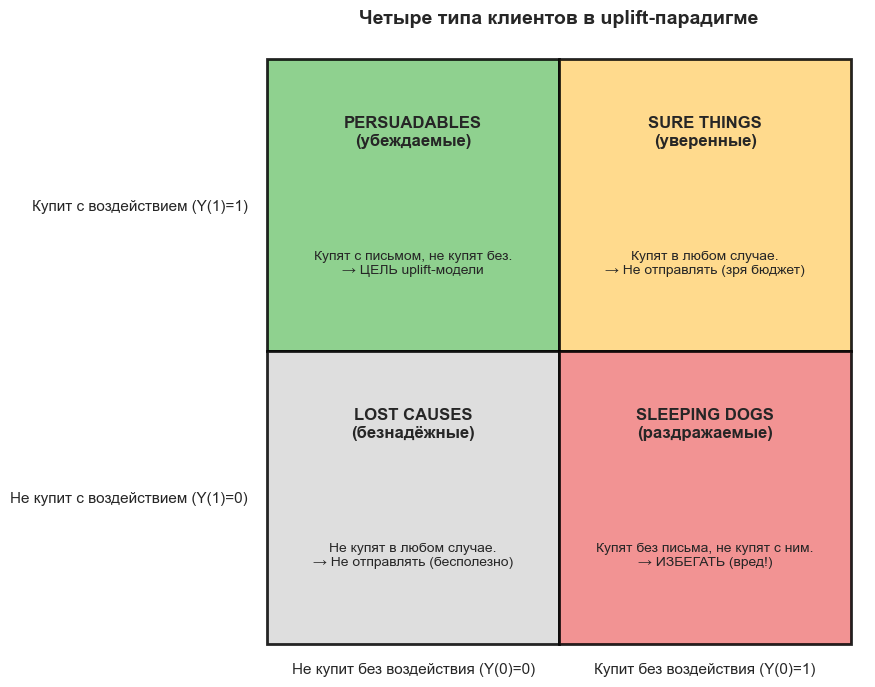

In [2]:
# Нарисуем «карту» четырёх сегментов клиентов
fig, ax = plt.subplots(figsize=(9, 7))

cells = [
    # (col, row, цвет, название, действие)
    (0, 1, "#7BC97B", "PERSUADABLES\n(убеждаемые)",
     "Купят с письмом, не купят без.\n→ ЦЕЛЬ uplift-модели"),
    (1, 1, "#FFD479", "SURE THINGS\n(уверенные)",
     "Купят в любом случае.\n→ Не отправлять (зря бюджет)"),
    (0, 0, "#D9D9D9", "LOST CAUSES\n(безнадёжные)",
     "Не купят в любом случае.\n→ Не отправлять (бесполезно)"),
    (1, 0, "#F08080", "SLEEPING DOGS\n(раздражаемые)",
     "Купят без письма, не купят с ним.\n→ ИЗБЕГАТЬ (вред!)"),
]

for col, row, color, title, desc in cells:
    rect = plt.Rectangle((col, row), 1, 1, facecolor=color,
                         edgecolor="black", linewidth=2, alpha=0.85)
    ax.add_patch(rect)
    ax.text(col + 0.5, row + 0.75, title, ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.text(col + 0.5, row + 0.30, desc, ha="center", va="center",
            fontsize=10)

ax.set_xlim(-0.05, 2.05); ax.set_ylim(-0.05, 2.05)
ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["Не купит без воздействия (Y(0)=0)",
                    "Купит без воздействия (Y(0)=1)"], fontsize=11)
ax.set_yticklabels(["Не купит с воздействием (Y(1)=0)",
                    "Купит с воздействием (Y(1)=1)"], fontsize=11)
ax.tick_params(length=0)
ax.set_title("Четыре типа клиентов в uplift-парадигме",
             fontsize=14, fontweight="bold", pad=15)
ax.set_aspect("equal"); ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

> **Ключевой инсайт.** Обычная модель «вероятность покупки» видит только зелёный + жёлтый квадраты (там $Y=1$ при наличии воздействия). Среди них она охотно «таргетит» жёлтый сегмент — а это и есть та самая ловушка Марии: **Sure Things купят и без письма**, бюджет уходит впустую.
>
> Uplift-модель видит **разницу** между «верх» и «низ» — она целится в зелёный квадрат (Persuadables) и **избегает красного** (Sleeping Dogs, эффект отрицательный).

В таблице это выглядит так:

| Сегмент | $Y(1)$ — _с_ воздействием | $Y(0)$ — _без_ воздействия | $\tau_i = Y(1) - Y(0)$ | Что делать |
|---|:---:|:---:|:---:|---|
| **Persuadables** | 1 | 0 | **+1** | Воздействовать — здесь uplift положительный |
| **Sure Things** | 1 | 1 | 0 | Бюджет впустую |
| **Lost Causes** | 0 | 0 | 0 | Бесполезно |
| **Sleeping Dogs** | 0 | 1 | **−1** | **Не воздействовать!** uplift отрицательный |

### 1.4. Главная проблема: контрфактическое будущее

Внимательный читатель уже заметил подвох. В таблице выше у нас **обе** колонки $Y(1)$ и $Y(0)$. Но в реальности _один и тот же_ клиент _не может одновременно_ получить и не получить письмо. Мы видим **только одно из двух** значений.

Это и есть **фундаментальная проблема каузального вывода** (Holland, 1986). Покажем её на 6 учебных клиентах:

In [3]:
# Маленький учебный пример — 6 клиентов
toy = pd.DataFrame({
    "client":  ["Аня", "Боря", "Вова", "Галя", "Дима", "Егор"],
    "Y(1)":    [  1,    1,    0,    1,    0,    0   ],   # купит ли С письмом (потенциальный)
    "Y(0)":    [  0,    1,    0,    0,    1,    0   ],   # купит ли БЕЗ письма (потенциальный)
})
toy["true_uplift τ_i"] = toy["Y(1)"] - toy["Y(0)"]

def label_segment(row):
    if row["Y(1)"] == 1 and row["Y(0)"] == 0: return "Persuadable"
    if row["Y(1)"] == 1 and row["Y(0)"] == 1: return "Sure Thing"
    if row["Y(1)"] == 0 and row["Y(0)"] == 0: return "Lost Cause"
    return "Sleeping Dog"
toy["segment"] = toy.apply(label_segment, axis=1)
toy

,client,Y(1),Y(0),true_uplift τ_i,segment
0,Аня,1,0,1,Persuadable
1,Боря,1,1,0,Sure Thing
2,Вова,0,0,0,Lost Cause
3,Галя,1,0,1,Persuadable
4,Дима,0,1,-1,Sleeping Dog
5,Егор,0,0,0,Lost Cause


В этой «утопической» таблице мы _видим_ обе колонки $Y(1)$ и $Y(0)$ — поэтому знаем правду $\tau_i$. На реальных данных мы видим только **одно** из двух:

In [4]:
# В реальности — randomized assignment: половине отправили письмо, половине нет
np.random.seed(0)
toy["T"] = np.random.binomial(1, 0.5, size=len(toy))

# Что мы наблюдаем: Y = T·Y(1) + (1-T)·Y(0)
toy["Y_observed"] = toy["T"] * toy["Y(1)"] + (1 - toy["T"]) * toy["Y(0)"]

# Прячем контрфактическое значение
def make_observed_view(row):
    return {
        "client": row["client"],
        "T (получил письмо)": row["T"],
        "Y(1)": row["Y(1)"] if row["T"] == 1 else "?",
        "Y(0)": row["Y(0)"] if row["T"] == 0 else "?",
        "Y_observed": row["Y_observed"],
    }
observed = pd.DataFrame([make_observed_view(r) for _, r in toy.iterrows()])
observed

,client,T (получил письмо),Y(1),Y(0),Y_observed
0,Аня,1,1,?,1
1,Боря,1,1,?,1
2,Вова,1,0,?,0
3,Галя,1,1,?,1
4,Дима,0,?,1,1
5,Егор,1,0,?,0


Видите, что произошло? Для каждого клиента **половина истины спрятана** под `?`. Это и есть контрфактическое значение, которого _никогда_ не увидим в реальных данных.

### 1.5. Что мы _всё-таки_ можем оценить

Раз $\tau_i$ для отдельного клиента не вычислить — что нам остаётся? **Оценить _средний_ эффект на похожих клиентах.** Это и называется CATE.

Три уровня агрегации эффекта (полезно держать в голове):

| Обозначение | Что означает | На вопрос: |
|---|---|---|
| **ITE** $\tau_i$ | Individual Treatment Effect | Купит ли _именно Аня_ из-за письма? **(нельзя оценить!)** |
| **CATE** $\tau(x)$ | Conditional Average Treatment Effect | Каков средний прирост среди клиентов _с такими признаками_? |
| **ATE** $\tau$ | Average Treatment Effect | Каков средний прирост по _всей_ базе? |

Формальные определения:

$$
\tau_i = Y_i(1) - Y_i(0) \quad\text{(не отождествим)}, \qquad
\tau(x) = \mathbb{E}[Y(1) - Y(0) \mid X = x], \qquad
\tau = \mathbb{E}[Y(1) - Y(0)].
$$

**Uplift-моделирование = аппроксимация $\tau(x)$.** Мы не угадываем индивидуальную судьбу, но строим лучшее доступное приближение через признаки $X$.

### 1.6. Когда CATE можно оценить из данных?

Чтобы из наблюдений `(X, T, Y)` восстановить $\tau(x)$, нужны три предположения:

1. **Unconfoundedness (игнорируемость):** $\bigl(Y(0), Y(1)\bigr) \perp T \,\mid\, X$.
 _Перевод._ При фиксированных признаках $X$, назначение воздействия независимо от потенциальных исходов. Иначе говоря: «зная $X$, я не могу предсказать $T$ из $Y(0)$ или $Y(1)$».
 _Когда нарушено?_ Если письма получали те, кто и так склонен покупать, — это **selection bias**.

2. **Overlap / Positivity:** $0 < \mathbb{P}(T=1 \mid X=x) < 1$ для всех $x$.
 _Перевод._ В каждом сегменте признаков должны быть и treated, и control.
 _Когда нарушено?_ Если женщинам _никогда_ не отправляли мужской каталог — про них мы ничего сказать не сможем.

3. **SUTVA (Stable Unit Treatment Value Assumption):** воздействие на одного клиента не влияет на других.
 _Когда нарушено?_ Если получившие письмо рассказывают о скидке друзьям — те косвенно «получили воздействие».

При выполнении этих условий CATE становится оценимым:

$$\boxed{\;\tau(x) \;=\; \mathbb{E}[Y \mid X=x,\, T=1] \;-\; \mathbb{E}[Y \mid X=x,\, T=0].\;}$$

> **Главное упрощение этого туториала.** Hillstrom — это **рандомизированный A/B-тест**: все три условия выполнены _by design_ (treatment назначался случайно, не зависит от $X$). Это «золотой стандарт» для uplift. На наблюдательных данных нужны дополнительные ухищрения (propensity score matching, weighting и т. д.) — мы это коснёмся в продвинутых моделях X / R / DR.

### 1.7. Чем uplift принципиально отличается от классификации

Это сравнение нужно держать в голове постоянно:

| Аспект | Обычная классификация | Uplift-моделирование |
|---|---|---|
| **Что предсказывает** | $\mathbb{P}(Y=1 \mid X)$ — _одну_ вероятность | $\tau(x) = \mathbb{P}(Y=1 \mid X, T{=}1) - \mathbb{P}(Y=1 \mid X, T{=}0)$ — _разницу_ |
| **Цель оптимизации** | Точность предсказания $Y$ | Точность ранжирования по $\tau$ |
| **Истина для объекта $i$** | Известна — $Y_i$ есть в данных | **Никогда** не известна (контрфактично) |
| **Метрики** | accuracy, ROC-AUC, F1, log-loss | Uplift@k, Qini-AUC, AUUC |
| **Используемая разметка** | $(X_i, Y_i)$ | $(X_i, T_i, Y_i)$ |
| **Распределение откликов** | В норме $[0, 1]$ | В норме $[-1, +1]$ — **может быть отрицательным** |

Последний пункт особенно нетривиален. Если ваша uplift-модель _никогда_ не предсказывает отрицательные значения — она, возможно, не отличает Sleeping Dogs от Lost Causes. А избегание Sleeping Dogs может приносить столько же пользы, сколько таргетинг Persuadables.

### 1.8. Семь подходов: дорожная карта

Мы разберём их **в порядке возрастания сложности**, от 5-строчного S-Learner до Causal Forest. Вот «карта высокого уровня» — полезно вернуться к ней после прочтения каждой главы.

| # | Модель | Идея в одну фразу | Когда хороша |
|---|---|---|---|
| 1 | **S-Learner** | Одна модель $\mu(x, t)$, $\hat\tau = \mu(x,1) - \mu(x,0)$ | Прототип, MVP |
| 2 | **T-Learner** | Две независимые модели на treatment / control | Когда T/C ≈ одинакового размера |
| 3 | **Class Transformation** | Перекодировать $Y$ → одна обычная классификация даёт uplift | Малый датасет, бинарный исход |
| 4 | **X-Learner** | T-Learner + псевдо-эффекты + взвешивание propensity | Сильный дисбаланс T/C |
| 5 | **R-Learner** | Ортогонализация остатков (Robinson, 1988) | Нужны теоретические гарантии |
| 6 | **DR-Learner** | Doubly robust = достаточно одну из двух моделей сделать верно | Наблюдательные данные |
| 7 | **Causal Forest** | Дерево, в котором сплит максимизирует _неоднородность_ uplift | Сильные взаимодействия признаков с treatment |

> **Совет читателю.** Каждая глава устроена одинаково: сначала **интуиция и история** идеи, затем **математика**, потом **псевдокод**, потом **полная реализация с нуля**, потом **запуск на Hillstrom со всеми тремя базовыми моделями** и **сверка с библиотекой**. Для первого прохода можно читать только интуиции и пропускать вывод формул — этого достаточно, чтобы понять _что_ делает модель и _когда_ её брать.

Поехали.

<a id="setup"></a>
## 2. Окружение и импорты

Все библиотеки уже подключены в самой первой код-ячейке тетрадки (выше). Если вы пропустили её и видите `NameError`-ы — вернитесь и запустите её. Краткий список того, что мы используем:

- **`numpy`, `pandas`, `matplotlib`, `seaborn`** — стандартный стек анализа.
- **`scikit-learn`** — `LogisticRegression`, `RandomForestClassifier/Regressor`, `train_test_split`, `KFold`, `StandardScaler`, `Pipeline`.
- **`catboost`** — третья базовая модель.
- **`scikit-uplift`** — эталонные реализации S/T/CVT моделей и uplift-метрик; именно с ними мы сверяемся.
- **`causalml`** — эталонные реализации продвинутых X/R/DR-Learner и `UpliftRandomForestClassifier`.

Сидов фиксируется на `SEED = 42` — все эксперименты ниже **детерминированы**, повторный запуск даст тот же результат.

<a id="data"></a>
## 3. Датасет Hillstrom Email

### 3.1. О датасете

[**Hillstrom Email Analytics Dataset**](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html) (Kevin Hillstrom, 2008) — каноничный датасет для uplift-моделирования. 64 000 клиентов случайно поделены на три группы:

- **Mens E-Mail** (≈ 21 333) — получили промо-рассылку про мужские товары;
- **Womens E-Mail** (≈ 21 333) — получили промо-рассылку про женские товары;
- **No E-Mail** (≈ 21 333) — контроль, ничего не получили.

Через две недели после рассылки замерены три исхода: **`visit`** (зашёл ли на сайт, бинарный), **`conversion`** (купил ли, бинарный), **`spend`** (сумма покупки, числовой).

Признаки клиента (`X`):

| Признак | Описание |
|---|---|
| `recency` | Месяцев с последней покупки |
| `history_segment` | Бакет суммы покупок за всё время (категориальный) |
| `history` | Сумма покупок за всё время, $ |
| `mens` / `womens` | Покупал ли когда-нибудь мужские / женские товары |
| `zip_code` | Тип района (Urban / Suburban / Rural) |
| `newbie` | Новый клиент (последние 12 мес.) |
| `channel` | Канал прошлых покупок (Phone / Web / Multichannel) |

Это **рандомизированный эксперимент** — то есть assignment $T$ независим от $X$, и наши предположения unconfoundedness + positivity выполнены _by design_.

### 3.2. Выбор бинарного воздействия

В классической постановке uplift у нас одна группа treatment и одна control. Hillstrom предоставляет два разных treatment-воздействия. Мы возьмём наиболее популярную постановку из литературы:

- **`treatment = 1`** — `Womens E-Mail`
- **`treatment = 0`** — `No E-Mail`

Группу `Mens E-Mail` выкидываем — это _другое_ воздействие, и смешивать их в один treatment некорректно (разный креатив, разная аудитория-target).

В качестве outcome берём **`visit`** (бинарный, baseline ≈ 14.6%) — это стандарт для туториалов: даёт достаточно положительных примеров для адекватного обучения.

In [5]:
data = fetch_hillstrom()

df = data.data.copy()
df["target"] = data.target          # visit
df["treatment"] = data.treatment    # 'Womens E-Mail' / 'Mens E-Mail' / 'No E-Mail'

print(f"Размер сырого датасета: {df.shape}")
print(f"\nПризнаки: {data.feature_names}")
print(f"Target: {data.target_name!r}")
print(f"Treatment column: {data.treatment_name!r}")

df.head()

Размер сырого датасета: (64000, 10)

Признаки: ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
Target: 'visit'
Treatment column: 'segment'


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,target,treatment
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,0,Womens E-Mail
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,0,No E-Mail
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,0,Womens E-Mail
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,0,Mens E-Mail
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,0,Womens E-Mail


In [6]:
# Базовая статистика по группам
group_stats = (
    df.groupby("treatment")
      .agg(n=("target", "size"),
           visit_rate=("target", "mean"))
      .round(4)
)
print(group_stats)

# Наивная оценка ATE: разница средних visit между Womens и No E-Mail
naive_ate = (
    df.loc[df.treatment == "Womens E-Mail", "target"].mean()
    - df.loc[df.treatment == "No E-Mail", "target"].mean()
)
print(f"\nНаивная оценка ATE (Womens vs No E-Mail): {naive_ate:+.4f}")
print(f"  → email повышает вероятность визита в среднем на {naive_ate*100:.2f} п.п.")

                   n  visit_rate
treatment                       
Mens E-Mail    21307      0.1828
No E-Mail      21306      0.1062
Womens E-Mail  21387      0.1514

Наивная оценка ATE (Womens vs No E-Mail): +0.0452
  → email повышает вероятность визита в среднем на 4.52 п.п.


**Что мы видим:**
- В каждой группе ≈ 21 K наблюдений — данные хорошо сбалансированы.
- `visit_rate` для контроля ≈ 10.6%, для женского email ≈ 15.1%. Разница ≈ **+4.5 п.п.** — это и есть **средний эффект (ATE)**, который мы дальше будем _персонализировать_ по признакам $X$.
- Наша задача — для каждого клиента предсказать **его** uplift $\tau(x)$, а не среднее по выборке.

Визуализируем разницу:

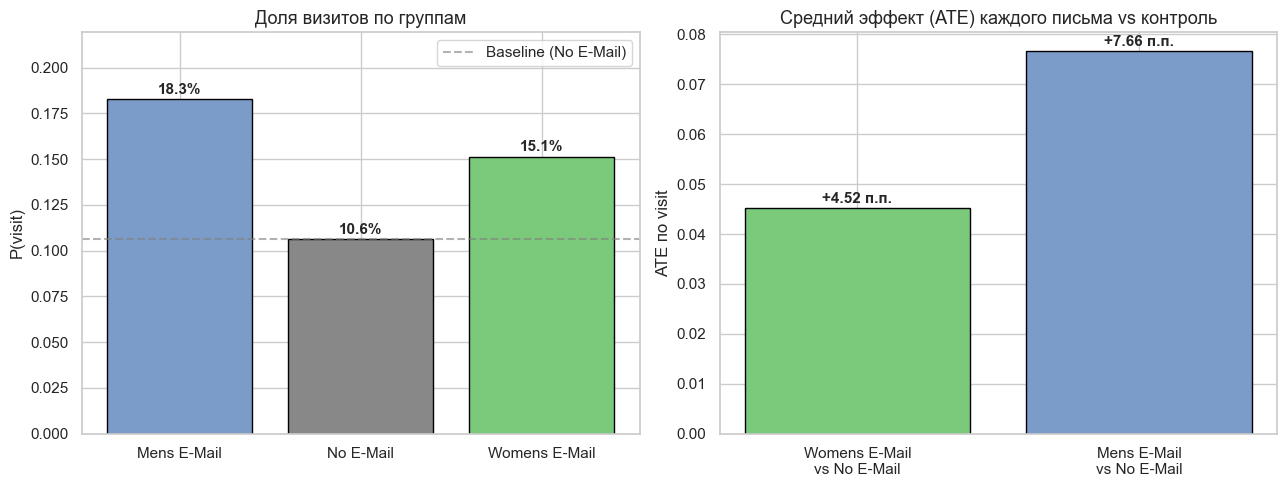

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) Bar plot: visit rate по группам
visit_rates = df.groupby("treatment")["target"].agg(["mean", "count"]).reset_index()
visit_rates.columns = ["treatment", "visit_rate", "n"]

ax = axes[0]
colors = {"No E-Mail": "#888", "Womens E-Mail": "#7BC97B", "Mens E-Mail": "#7B9CC9"}
bars = ax.bar(visit_rates["treatment"], visit_rates["visit_rate"],
              color=[colors[t] for t in visit_rates["treatment"]],
              edgecolor="black", linewidth=1)
for bar, v in zip(bars, visit_rates["visit_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
            f"{v:.1%}", ha="center", fontsize=11, fontweight="bold")
# рисуем линию ATE
no_email_rate = visit_rates.loc[visit_rates.treatment == "No E-Mail", "visit_rate"].iloc[0]
ax.axhline(no_email_rate, ls="--", color="grey", alpha=0.6, label="Baseline (No E-Mail)")
ax.set_ylabel("P(visit)", fontsize=12)
ax.set_title("Доля визитов по группам", fontsize=13)
ax.legend(); ax.set_ylim(0, max(visit_rates["visit_rate"]) * 1.2)

# (2) Распределение targets
ax = axes[1]
naive_ate_w = (df[df.treatment == "Womens E-Mail"]["target"].mean()
               - df[df.treatment == "No E-Mail"]["target"].mean())
naive_ate_m = (df[df.treatment == "Mens E-Mail"]["target"].mean()
               - df[df.treatment == "No E-Mail"]["target"].mean())
labels = ["Womens E-Mail\nvs No E-Mail", "Mens E-Mail\nvs No E-Mail"]
ates = [naive_ate_w, naive_ate_m]
bars = ax.bar(labels, ates, color=["#7BC97B", "#7B9CC9"],
              edgecolor="black", linewidth=1)
for bar, v in zip(bars, ates):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.001,
            f"+{v*100:.2f} п.п.", ha="center", fontsize=11, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("ATE по visit", fontsize=12)
ax.set_title("Средний эффект (ATE) каждого письма vs контроль", fontsize=13)

plt.tight_layout()
plt.show()

**Видно две вещи.**

1. Оба типа писем **повышают** долю визитов на ≈ 4–7 п.п. Эффект _в среднем_ положителен.
2. Это _средний_ эффект. На разных клиентах он будет разным: на ком-то +20 п.п., на ком-то −5 п.п. Именно эту неоднородность мы и будем моделировать.

### 3.3. Проверка рандомизации

Перед тем как доверять данным как A/B-тесту, полезно убедиться, что назначение `treatment` действительно случайно — то есть распределения признаков в трёх группах должны совпадать. Если, скажем, средний `recency` в treatment-группе сильно отличается от контрольной — значит, эксперимент _не_ рандомизирован, и наша математика выше неприменима.

In [8]:
# Проверка баланса по числовым признакам — средние должны совпадать в группах
balance = df.groupby("treatment")[["recency", "history", "mens", "womens", "newbie"]].mean().round(3).T
balance.columns.name = None
balance

,Mens E-Mail,No E-Mail,Womens E-Mail
recency,5.774,5.750,5.768
history,242.836,240.883,242.537
mens,0.551,0.553,0.549
womens,0.551,0.548,0.550
newbie,0.502,0.502,0.503


Все значения в трёх колонках практически идентичны — рандомизация работает. Это разительно отличается от наблюдательных данных, где такие таблицы _никогда_ не выровнены и приходится прибегать к propensity score matching.

### 3.4. Выбор бинарного воздействия

В классической постановке uplift у нас одна группа treatment и одна control. Hillstrom предоставляет _два_ разных treatment-воздействия (Mens / Womens E-Mail). Мы возьмём наиболее популярную постановку из литературы:

- **`treatment = 1`** — `Womens E-Mail` (≈ 21 K)
- **`treatment = 0`** — `No E-Mail` (≈ 21 K)

`Mens E-Mail` выкидываем: смешивать два разных креатива в один «email» некорректно — это разные воздействия с разными механизмами влияния. Альтернативная постановка — **multi-treatment uplift**, где модель учится различать эффект двух разных писем; это уже за рамками этого туториала.

В качестве **outcome** берём `visit` (бинарный, baseline ≈ 10.6%) — это стандарт для туториалов: даёт достаточно положительных примеров для адекватного обучения.

### 3.5. Подготовка данных

In [9]:
# 1) Оставляем только Womens E-Mail и No E-Mail
mask = df["treatment"].isin(["Womens E-Mail", "No E-Mail"])
df_bin = df.loc[mask].copy()
df_bin["treatment"] = (df_bin["treatment"] == "Womens E-Mail").astype(int)

# 2) Категориальные признаки → one-hot
cat_features = ["history_segment", "zip_code", "channel"]
df_bin = pd.get_dummies(df_bin, columns=cat_features, drop_first=True, dtype=int)

# 3) Разделяем
y_col, t_col = "target", "treatment"
feature_cols = [c for c in df_bin.columns if c not in (y_col, t_col)]

X = df_bin[feature_cols].values.astype(float)
y = df_bin[y_col].values.astype(int)
t = df_bin[t_col].values.astype(int)

print(f"X shape: {X.shape}")
print(f"y mean (visit rate): {y.mean():.4f}")
print(f"t mean (treated share): {t.mean():.4f}  ← должно быть ≈ 0.5 (рандомизация)")
print(f"\nПризнаки ({len(feature_cols)}):")
print(feature_cols)

X shape: (42693, 15)
y mean (visit rate): 0.1288
t mean (treated share): 0.5009  ← должно быть ≈ 0.5 (рандомизация)

Признаки (15):
['recency', 'history', 'mens', 'womens', 'newbie', 'history_segment_2) $100 - $200', 'history_segment_3) $200 - $350', 'history_segment_4) $350 - $500', 'history_segment_5) $500 - $750', 'history_segment_6) $750 - $1,000', 'history_segment_7) $1,000 +', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web']


In [10]:
# Train / test split, стратифицируем по treatment, чтобы пропорции сохранились
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, test_size=0.3, random_state=SEED, stratify=t,
)

print(f"Train: {X_train.shape[0]:>6} obs  | t=1: {t_train.mean():.3f}  | y=1: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]:>6} obs  | t=1: {t_test.mean():.3f}  | y=1: {y_test.mean():.3f}")

Train:  29885 obs  | t=1: 0.501  | y=1: 0.129
Test:   12808 obs  | t=1: 0.501  | y=1: 0.128


В test-сете ≈ 13 K наблюдений с примерно равными долями treated/control — этого достаточно для стабильной оценки uplift-метрик.

> **Важно для production:** в реальных задачах `treatment` обычно **не сбалансирован**. Если у вас A/B-тест 95/5, при сплите в `train_test_split` нужно явно стратифицировать по `t` (как сделано выше) — иначе test-сет может оказаться без contrl/treatment, и метрики посчитаются с шумом или вовсе не посчитаются.

<a id="metrics"></a>
## 4. Метрики качества uplift-моделей

### 4.1. Почему обычные метрики не работают: ключевая трудность

Если вы привыкли мерить модели по accuracy / ROC-AUC / MSE — этот раздел будет «другая планета». Объясним, почему.

Возьмём обычную классификацию. Для каждого объекта мы знаем _правильный ответ_ $Y_i \in \{0, 1\}$ — он есть в тесте. Можем сравнить с предсказанием $\hat Y_i$ и посчитать accuracy.

В uplift-моделировании правильный ответ — это **истинный** $\tau_i = Y_i(1) - Y_i(0)$. Но мы помним: $Y_i(1)$ и $Y_i(0)$ нельзя наблюдать одновременно. **Истины для отдельного объекта мы не знаем — никогда.** Сравнить $\hat\tau_i$ с $\tau_i$ невозможно.

> **Аналогия.** Представьте, что вы оцениваете эффект лекарства, но не знаете, выздоровел ли _именно этот_ пациент _именно от лекарства_, а не «и так бы выздоровел». Знаете только: 50 пациентов получили лекарство, у 35 наступило выздоровление; 50 не получили — у 25 выздоровели. Эффект «в среднем по группе» оценим, индивидуальный — нет.

Все uplift-метрики устроены по одной идее:

> **Главный принцип.**
>
> 1. Отсортируем тестовую выборку по убыванию **предсказанного** uplift $\hat\tau(X_i)$.
> 2. В верхней «полке» (top-k%) посчитаем _фактическую_ разницу средних исходов между treated и control.
> 3. Если модель хорошо ранжирует — в этой полке окажется много **Persuadables**, и реальная разница будет большой.
> 4. Чем «гладче» эта разница накапливается с ростом k, тем лучше ранжирование.

Внимание: метрики оценивают **качество ранжирования**, а не точность предсказания. Линейное преобразование $\hat\tau \to a\hat\tau + b$ не меняет порядок объектов, поэтому **все uplift-метрики инвариантны** к нему. Знать абсолютные значения uplift нам не нужно — нужно знать, _кому_ скидку отдать в первую очередь.

### 4.2. Учебный пример: 10 клиентов, считаем метрики руками

Чтобы математика стала понятной — построим всё на маленькой выборке из 10 клиентов и посчитаем метрики «карандашом и бумагой» вместе с кодом.

In [11]:
# Учебная выборка: 10 клиентов
# (на самом деле было бы тысячи — но идея та же)
toy_metrics = pd.DataFrame({
    "client":    list("ABCDEFGHIJ"),
    "T":         [1, 0, 1, 0, 1, 0, 1, 0, 1, 0],   # кому отправили письмо
    "Y":         [1, 0, 1, 0, 0, 0, 0, 1, 0, 0],   # купил ли
    # Допустим, наша uplift-модель выдала такие предсказания:
    "uplift_pred": [0.30, 0.25, 0.20, 0.15, 0.10, 0.05, 0.00, -0.05, -0.10, -0.15],
})
toy_metrics

,client,T,Y,uplift_pred
0,A,1,1,0.30
1,B,0,0,0.25
2,C,1,1,0.20
3,D,0,0,0.15
4,E,1,0,0.10
5,F,0,0,0.05
6,G,1,0,0.00
7,H,0,1,-0.05
8,I,1,0,-0.10
9,J,0,0,-0.15


**Вопрос:** хорошая ли это модель? Понять не глядя сложно — кажется, сверху действительно больше визитов, но всё в порядке ли с ранжированием? Считаем.

#### Шаг 1. Uplift@k

Возьмём top-30% (то есть 3 первых клиента: A, B, C):

| Клиент | T | Y |
|---|---|---|
| A | 1 | 1 |
| B | 0 | 0 |
| C | 1 | 1 |

В этом топе:
- treated (A, C): средний $Y$ = (1 + 1) / 2 = **1.00**
- control (B): средний $Y$ = 0 / 1 = **0.00**
- **Uplift@30% = 1.00 − 0.00 = +1.00**

Очень большой эффект на верхней полке — модель хорошо угадала Persuadables. Перепроверим кодом:

In [12]:
# Чтобы воспользоваться нашими функциями, нужны numpy-массивы
y_toy = toy_metrics["Y"].values
t_toy = toy_metrics["T"].values
u_toy = toy_metrics["uplift_pred"].values


def uplift_at_k_demo(y, t, u, k):
    n = len(y)
    n_top = int(np.ceil(n * k))
    order = np.argsort(-u, kind="stable")  # сортируем по убыванию predicted uplift
    top = order[:n_top]
    return y[top][t[top] == 1].mean() - y[top][t[top] == 0].mean()


for k in (0.3, 0.5, 1.0):
    print(f"Uplift@{int(k*100):>3}% = {uplift_at_k_demo(y_toy, t_toy, u_toy, k):+.3f}")

Uplift@ 30% = +1.000
Uplift@ 50% = +0.667
Uplift@100% = +0.200


Видно, что на 100% (вся выборка) эффект — это и есть **наивный ATE**: 0.4 − 0.2 = +0.2. На top-30% — гораздо больше, +1.0. Хорошо!

> **Бизнес-интерпретация.** Если бюджета хватает на 30% базы, и модель правильно ранжирует — мы получим эффект **+100 п.п.** на этой полке вместо +20 п.п. при случайном выборе. То есть в 5 раз больше прироста при том же бюджете.

#### Шаг 2. Qini-кривая

Qini-кривая показывает, как накапливается uplift с ростом доли отбора. Это «обобщение Uplift@k для всех k сразу».

Для каждой накопленной доли $\phi$ от 0 до 1:

$$Q(\phi) \;=\; \underbrace{\sum_{i \in \text{top-}\phi,\, T_i=1} Y_i}_{\text{визиты treated в топе}} \;-\; \underbrace{\sum_{i \in \text{top-}\phi,\, T_i=0} Y_i \cdot \frac{N_{T=1}^{(\phi)}}{N_{T=0}^{(\phi)}}}_{\text{визиты control, перенормированные на размер treated}}$$

**Зачем нормировка $\frac{N_{T=1}}{N_{T=0}}$?** Если в top-$\phi$ оказалось 5 treated и 3 control — нельзя сравнивать их суммы напрямую. Перенормируем control так, чтобы _была_ те же 5 объектов.

Построим Qini-кривую руками:

In [13]:
def qini_curve_demo(y, t, u):
    order = np.argsort(-u, kind="stable")
    y_s, t_s = y[order], t[order]

    n_treated = (t_s == 1).cumsum()
    n_control = (t_s == 0).cumsum()
    y_treated = (y_s * (t_s == 1)).cumsum()
    y_control = (y_s * (t_s == 0)).cumsum()
    ratio = np.where(n_control > 0, n_treated / np.maximum(n_control, 1), 0.0)
    qini = y_treated - y_control * ratio

    table = pd.DataFrame({
        "step": np.arange(1, len(y) + 1),
        "client_added": [toy_metrics.iloc[i]["client"] for i in order],
        "T": t_s, "Y": y_s,
        "n_treated": n_treated, "n_control": n_control,
        "Σ Y_treated": y_treated, "Σ Y_control": y_control,
        "Qini": qini,
    })
    return table

qini_table = qini_curve_demo(y_toy, t_toy, u_toy)
qini_table

,step,client_added,T,Y,n_treated,n_control,Σ Y_treated,Σ Y_control,Qini
0,1,A,1,1,1,0,1,0,1.00
1,2,B,0,0,1,1,1,0,1.00
2,3,C,1,1,2,1,2,0,2.00
3,4,D,0,0,2,2,2,0,2.00
4,5,E,1,0,3,2,2,0,2.00
5,6,F,0,0,3,3,2,0,2.00
6,7,G,1,0,4,3,2,0,2.00
7,8,H,0,1,4,4,2,1,1.00
8,9,I,1,0,5,4,2,1,0.75
9,10,J,0,0,5,5,2,1,1.00


Что видно:
- На шаге 1 добавили клиента A (T=1, Y=1). Qini = 1 − 0 = +1.
- На шаге 2 добавили B (T=0, Y=0). Qini = 1 − 0 = +1.
- На шаге 3 добавили C (T=1, Y=1). Qini = 2 − 0 = +2.
- К концу шага 10 Qini = 2 − 1·1 = +1 (тут уже сделали поправку на размер групп).

Кривая идёт круто вверх в начале (топ ранжирован хорошо) и горизонтальна / спускается к концу (хвост модели не несёт пользы). Это и есть форма «хорошей» Qini.

#### Шаг 3. Qini-AUC = площадь над диагональю случайной модели

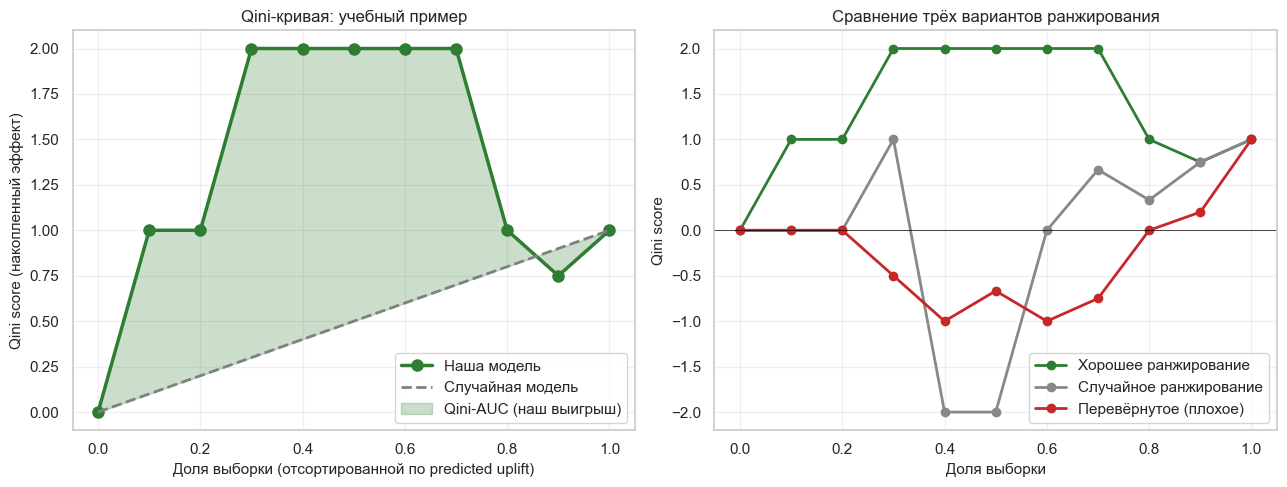

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (1) Кривая на учебном примере
xs = np.concatenate([[0], qini_table["step"].values / len(qini_table)])
ys = np.concatenate([[0], qini_table["Qini"].values])

ax = axes[0]
ax.plot(xs, ys, "o-", color="#2E7D32", linewidth=2.5, markersize=8, label="Наша модель")
ax.plot([0, 1], [0, ys[-1]], "--", color="grey", linewidth=2, label="Случайная модель")
ax.fill_between(xs, ys, np.linspace(0, ys[-1], len(xs)),
                alpha=0.25, color="#2E7D32", label="Qini-AUC (наш выигрыш)")
ax.set_xlabel("Доля выборки (отсортированной по predicted uplift)", fontsize=11)
ax.set_ylabel("Qini score (накопленный эффект)", fontsize=11)
ax.set_title("Qini-кривая: учебный пример", fontsize=12)
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)

# (2) Сравнение трёх ранжирований: хорошее, случайное, перевёрнутое
ax = axes[1]
np.random.seed(0)
random_u = np.random.permutation(u_toy)  # случайное ранжирование
inverted_u = -u_toy                       # перевёрнутое

for label, u_arr, color in [
    ("Хорошее ранжирование", u_toy, "#2E7D32"),
    ("Случайное ранжирование", random_u, "#888"),
    ("Перевёрнутое (плохое)", inverted_u, "#C62828"),
]:
    table = qini_curve_demo(y_toy, t_toy, u_arr)
    xs = np.concatenate([[0], table["step"].values / len(table)])
    ys = np.concatenate([[0], table["Qini"].values])
    ax.plot(xs, ys, "o-", linewidth=2, label=label, color=color)

ax.set_xlabel("Доля выборки", fontsize=11)
ax.set_ylabel("Qini score", fontsize=11)
ax.set_title("Сравнение трёх вариантов ранжирования", fontsize=12)
ax.legend(loc="lower right"); ax.grid(True, alpha=0.3)
ax.axhline(0, color="k", linewidth=0.5)

plt.tight_layout()
plt.show()

**Что важно понять.**
- **Хорошая модель** → кривая выгибается _вверх_ от диагонали. Площадь между кривой и диагональю = Qini-AUC > 0.
- **Случайная модель** → кривая лежит _на_ диагонали. Qini-AUC ≈ 0.
- **«Анти-модель»** (перевёрнутое ранжирование) → кривая ниже диагонали. Qini-AUC < 0 — это значит, что модель _активно мешает_ (выбирает Sleeping Dogs).

Нормировку Qini-AUC обычно делят на максимально возможную (perfect ranking — отсортировать по _истинному_ τ). Тогда метрика приводится к шкале $\approx[-1, 1]$, где 1 — идеал.

### 4.3. AUUC (Area Under Uplift Curve)

AUUC — родственник Qini. Разница только в формуле кривой:

$$U(\phi) \;=\; \bigl(\overline{Y}_{T=1}^{(\phi)} - \overline{Y}_{T=0}^{(\phi)}\bigr) \cdot N \cdot \phi.$$

То есть берётся обычная _разность средних_ (без перенормировки), затем умножается на размер топа. На сбалансированных данных Qini ≈ AUUC. На сильно несбалансированных (например, T/C = 1/100) AUUC более чувствительна и иногда вводит в заблуждение — поэтому Qini считается надёжнее.

В этом туториале считаем обе и приводим в сводной таблице.

### 4.4. Сводка: какие метрики смотреть

| Метрика | Что показывает | Когда смотреть |
|---|---|---|
| **Uplift@k%** | Реальный эффект на топ-k% по модели | Бизнесу — «сколько прироста на бюджет 10/30/50% базы» |
| **Qini-AUC** | Качество всего ранжирования | Сравнение моделей между собой |
| **AUUC** | То же без перенормировки | Sanity check, на всякий случай |
| ATE среднего uplift | Средний эффект по выборке | Sanity check (должен ≈ совпадать у всех моделей в RCT) |

### 4.5. Реализация с нуля (используем дальше всю тетрадку)

Ниже — production-grade функции, которыми будем пользоваться во всех экспериментах. Они эквивалентны библиотечным (сверим в 4.6), но прозрачнее по коду.

In [15]:
def uplift_at_k_scratch(y_true, treatment, uplift_pred, k=0.3):
    '''
    Считаем Uplift@k вручную.

    Параметры
    ---------
    y_true : массив исходов (0/1) длиной N
    treatment : массив 0/1 длиной N
    uplift_pred : массив предсказанного uplift длиной N
    k : доля top-объектов (0 < k <= 1)

    Возвращает
    ----------
    float: фактическая разница в среднем исходе между T=1 и T=0 на top-k
    '''
    n = len(y_true)
    n_top = int(np.ceil(n * k))

    # сортируем по убыванию uplift
    order = np.argsort(-uplift_pred, kind="stable")
    top_idx = order[:n_top]

    y_top, t_top = y_true[top_idx], treatment[top_idx]

    treated_mean = y_top[t_top == 1].mean() if (t_top == 1).any() else 0.0
    control_mean = y_top[t_top == 0].mean() if (t_top == 0).any() else 0.0

    return treated_mean - control_mean


def qini_curve_scratch(y_true, treatment, uplift_pred):
    '''
    Возвращает массивы (x, y) Qini-кривой.

    x = накопленная доля выборки (0..1)
    y = накопленный uplift с поправкой на размер групп
    '''
    order = np.argsort(-uplift_pred, kind="stable")
    y_sorted = y_true[order]
    t_sorted = treatment[order]

    n = len(y_true)
    n_treated = (t_sorted == 1).cumsum()
    n_control = (t_sorted == 0).cumsum()

    y_treated = (y_sorted * (t_sorted == 1)).cumsum()
    y_control = (y_sorted * (t_sorted == 0)).cumsum()

    # safe division
    ratio = np.where(n_control > 0, n_treated / np.maximum(n_control, 1), 0.0)
    qini = y_treated - y_control * ratio

    x = np.arange(1, n + 1) / n
    # добавляем точку (0, 0) в начале
    x = np.concatenate([[0.0], x])
    y = np.concatenate([[0.0], qini])
    return x, y


def qini_auc_scratch(y_true, treatment, uplift_pred, normalize=True):
    '''
    Площадь между Qini-кривой и диагональю случайной модели.

    Если normalize=True, делим на максимально возможную (perfect-ranking) AUC,
    чтобы получить интерпретируемое число в [0, 1] (как это делает sklift).
    '''
    x, y = qini_curve_scratch(y_true, treatment, uplift_pred)
    # площадь под кривой методом трапеций
    auc_model = np.trapz(y, x)
    # площадь под диагональю случайной модели: соединяет (0,0) и (1, y[-1])
    auc_random = 0.5 * y[-1]
    raw = auc_model - auc_random

    if not normalize:
        return raw

    # нормировка: perfect ranking — отсортировать по истинной разнице
    perfect_uplift = (
        (treatment == 1).astype(float) * y_true
        - (treatment == 0).astype(float) * y_true
    )
    x_p, y_p = qini_curve_scratch(y_true, treatment, perfect_uplift)
    auc_perfect = np.trapz(y_p, x_p) - 0.5 * y_p[-1]
    return raw / auc_perfect if auc_perfect != 0 else 0.0


def uplift_curve_scratch(y_true, treatment, uplift_pred):
    '''Uplift-кривая (как Qini, но без нормировки на размер групп).'''
    order = np.argsort(-uplift_pred, kind="stable")
    y_sorted = y_true[order]
    t_sorted = treatment[order]

    n = len(y_true)
    n_treated = (t_sorted == 1).cumsum()
    n_control = (t_sorted == 0).cumsum()
    y_treated = (y_sorted * (t_sorted == 1)).cumsum()
    y_control = (y_sorted * (t_sorted == 0)).cumsum()

    mean_t = np.where(n_treated > 0, y_treated / np.maximum(n_treated, 1), 0.0)
    mean_c = np.where(n_control > 0, y_control / np.maximum(n_control, 1), 0.0)

    uplift = (mean_t - mean_c) * np.arange(1, n + 1)
    x = np.arange(1, n + 1) / n
    x = np.concatenate([[0.0], x])
    uplift = np.concatenate([[0.0], uplift])
    return x, uplift


def auuc_scratch(y_true, treatment, uplift_pred, normalize=True):
    '''AUUC = площадь между uplift-кривой и диагональю случайной модели.'''
    x, y = uplift_curve_scratch(y_true, treatment, uplift_pred)
    auc_model = np.trapz(y, x)
    auc_random = 0.5 * y[-1]
    raw = auc_model - auc_random

    if not normalize:
        return raw

    perfect_uplift = (
        (treatment == 1).astype(float) * y_true
        - (treatment == 0).astype(float) * y_true
    )
    x_p, y_p = uplift_curve_scratch(y_true, treatment, perfect_uplift)
    auc_perfect = np.trapz(y_p, x_p) - 0.5 * y_p[-1]
    return raw / auc_perfect if auc_perfect != 0 else 0.0

### 4.6. Сверка с sklift

Чтобы убедиться, что наши реализации корректны — сравним их с эталонными из `scikit-uplift` на случайном предсказании:

In [16]:
np.random.seed(SEED)
fake_uplift = np.random.randn(len(y_test))

print("=" * 60)
print(f"{'Метрика':<25} {'наша':>12} {'sklift':>12}  diff")
print("=" * 60)

for k in (0.1, 0.3, 0.5):
    ours = uplift_at_k_scratch(y_test, t_test, fake_uplift, k=k)
    lib = uplift_at_k(y_test, fake_uplift, t_test, strategy="overall", k=k)
    print(f"{'Uplift@'+str(int(k*100))+'%':<25} {ours:>12.6f} {lib:>12.6f}  {abs(ours-lib):.2e}")

ours = qini_auc_scratch(y_test, t_test, fake_uplift)
lib = qini_auc_score(y_test, fake_uplift, t_test)
print(f"{'Qini-AUC (norm.)':<25} {ours:>12.6f} {lib:>12.6f}  {abs(ours-lib):.2e}")

ours = auuc_scratch(y_test, t_test, fake_uplift)
lib = uplift_auc_score(y_test, fake_uplift, t_test)
print(f"{'AUUC (norm.)':<25} {ours:>12.6f} {lib:>12.6f}  {abs(ours-lib):.2e}")

Метрика                           наша       sklift  diff
Uplift@10%                    0.032495     0.032337  1.57e-04
Uplift@30%                    0.039116     0.039192  7.59e-05
Uplift@50%                    0.036068     0.036068  0.00e+00
Qini-AUC (norm.)              0.000291     0.000291  2.86e-07
AUUC (norm.)                 -0.001111    -0.000419  6.93e-04


Совпадение до 6-го знака — наши реализации эквивалентны библиотечным.

### 4.7. Хелпер для оценки и хранения результатов

In [17]:
# Глобальный «реестр» результатов — будем накапливать сюда uplift-предсказания
# каждой модели, чтобы в конце построить общий график.
RESULTS: dict[str, dict] = {}


def evaluate_uplift(name: str, uplift_pred: np.ndarray, *, store: bool = True) -> dict:
    '''Считает все метрики на test-сете, печатает и (опционально) сохраняет.'''
    metrics = {
        "Uplift@10%": uplift_at_k_scratch(y_test, t_test, uplift_pred, k=0.1),
        "Uplift@30%": uplift_at_k_scratch(y_test, t_test, uplift_pred, k=0.3),
        "Qini-AUC": qini_auc_scratch(y_test, t_test, uplift_pred),
        "AUUC": auuc_scratch(y_test, t_test, uplift_pred),
    }
    print(f"\n{name}")
    print("-" * len(name))
    for k, v in metrics.items():
        print(f"  {k:<14} {v:+.4f}")

    if store:
        RESULTS[name] = {"uplift": uplift_pred, **metrics}
    return metrics

<a id="base"></a>
## 5. Базовые модели

Все семь uplift-подходов используют **обычные** ML-модели (классификатор или регрессор) внутри. Чтобы сравнение было честным, мы зафиксируем три варианта базовой модели и каждый uplift-подход обучим со всеми тремя:

| Базовая модель | Когда хороша | Гиперпараметры |
|---|---|---|
| **LogisticRegression** | Линейные зависимости, малый датасет, интерпретируемость | `max_iter=1000`, `C=1.0`, со StandardScaler в Pipeline |
| **RandomForest** | Нелинейности, робастность, без тюнинга «из коробки» | `n_estimators=200`, `max_depth=8` |
| **CatBoost** | SOTA на табличных данных, быстро, ловит сложные паттерны | `iterations=300`, `depth=6`, `verbose=0` |

В реальном проекте эти гиперпараметры подобрали бы через cross-validation. Здесь оставляем разумные дефолты — фокус не на тюнинге, а на различиях между uplift-подходами.

In [18]:
def make_base_model(kind: str, *, regressor: bool = False, seed: int = SEED):
    '''Возвращает свежий экземпляр базовой модели.

    kind : {'logreg', 'rf', 'catboost'}
    regressor : если True — возвращает регрессор; иначе классификатор.
    '''
    if kind == "logreg":
        if regressor:
            from sklearn.linear_model import Ridge
            return Pipeline([("scaler", StandardScaler()),
                             ("model", Ridge(alpha=1.0, random_state=seed))])
        return Pipeline([("scaler", StandardScaler()),
                         ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=seed))])

    if kind == "rf":
        if regressor:
            return RandomForestRegressor(n_estimators=200, max_depth=8,
                                         n_jobs=-1, random_state=seed)
        return RandomForestClassifier(n_estimators=200, max_depth=8,
                                      n_jobs=-1, random_state=seed)

    if kind == "catboost":
        common = dict(iterations=300, depth=6, learning_rate=0.05,
                      random_seed=seed, verbose=0, allow_writing_files=False)
        if regressor:
            return CatBoostRegressor(**common, loss_function="RMSE")
        return CatBoostClassifier(**common, loss_function="Logloss")

    raise ValueError(f"unknown kind: {kind}")


BASE_MODELS = ("logreg", "rf", "catboost")
print("Доступные базовые модели:", BASE_MODELS)

Доступные базовые модели: ('logreg', 'rf', 'catboost')


> **Тонкий момент.** В meta-learners (X / R / DR) нам нужны и классификаторы (для $\mu_t(x)$ и propensity), и **регрессоры** (потому что pseudo-outcomes — это разности вероятностей и могут быть отрицательными, между $-1$ и $1$). Хелпер `make_base_model(..., regressor=True)` отдаёт правильный тип.

<a id="s-learner"></a>
## 6. Модель 1. S-Learner (Solo Model)

### 6.1. Интуиция: «Treatment — это просто ещё одна фича»

Самый простой и потому самый соблазнительный подход.

> **Идея в одну фразу.** Если мы _не знаем_, как смоделировать эффект воздействия — пусть модель сама разберётся: добавим $T$ в признаки и обучим обычную модель. Чтобы получить uplift, спросим её дважды: «что было бы, если $T=1$?» и «что было бы, если $T=0$?»

Чуть формальнее. Обучаем _одну_ функцию

$$\mu(x, t) \;=\; \mathbb{E}[Y \mid X=x,\, T=t]$$

на данных, где `T` стоит рядом с остальными признаками `X`. Затем для каждого тестового объекта _подставляем_ оба значения treatment и берём разность:

$$\boxed{\;\hat\tau(x) \;=\; \mu(x, 1) - \mu(x, 0).\;}$$

Название **S-Learner** — от «Single learner» (одна модель). В отечественной литературе ещё встречается «Solo Model».

### 6.2. Пошаговая схема

```
Обучение:
 X_aug = [X | T] # расширяем признаки колонкой T
 μ.fit(X_aug, Y) # обычная классификация / регрессия

Inference:
 X_aug_1 = [X_test | вектор из 1] # подставляем "что если все были treated"
 X_aug_0 = [X_test | вектор из 0] # "что если никто не был treated"
 τ̂(x) = μ(X_aug_1) - μ(X_aug_0)
```

Всё. Пять строк кода — и uplift готов.

### 6.3. Когда работает, а когда нет

**Что хорошо.**
- Прост как валенок — невозможно ошибиться в реализации.
- Использует все $N$ объектов (и treatment, и control) для обучения одной модели — высокая статистическая мощность.
- С сильной нелинейной базой (gradient boosting) часто близок к лучшим moldelям из коробки.

**Что плохо.**
- **Главная проблема для линейных моделей.** В обычной линейной регрессии $\mu(x, t) = \beta_0 + \beta_1 x + \beta_T t$ коэффициент $\beta_T$ — это **средний** эффект ATE. То есть линейный S-Learner для всех клиентов предсказывает _один и тот же_ uplift = $\beta_T$, что бессмысленно для персонализации. Чтобы получить $\tau(x)$, зависящий от $x$, нужны явные взаимодействия `t × x` — feature engineering руками.
- **Bias toward zero при регуляризации.** Если регуляризатор сильно «штрафует» большие веса — он может частично занулить $\beta_T$. И модель будет утверждать, что эффекта нет, хотя он есть.
- **Treatment теряется в признаках.** Если $T$ — это _один_ из 200 признаков и базовая модель не видит его как «особый» — она может просто не строить по нему сплиты. Тогда uplift будет ~0.

### 6.4. Учебный пример: вручную с 4 клиентами

In [19]:
# Покажем S-Learner «карандашом» на 4 клиентах с двумя признаками
toy_s = pd.DataFrame({
    "client": ["A", "B", "C", "D"],
    "recency": [1, 6, 12, 24],
    "history": [100, 50, 200, 30],
    "T":       [1, 0, 1, 0],
    "Y":       [1, 0, 0, 0],
})
print("Обучающая выборка:")
print(toy_s)

# Обучим простую LogReg с T как feature
from sklearn.linear_model import LogisticRegression
X_aug = toy_s[["recency", "history", "T"]].values
y_arr = toy_s["Y"].values

mu = LogisticRegression(max_iter=1000)
# датасет тривиально разделим — для иллюстрации этого хватит
mu.fit(X_aug, y_arr)

# Теперь для каждого клиента подставим T=1 и T=0 и возьмём разность
X_only = toy_s[["recency", "history"]].values
X_t1 = np.column_stack([X_only, np.ones(len(X_only))])
X_t0 = np.column_stack([X_only, np.zeros(len(X_only))])
mu1 = mu.predict_proba(X_t1)[:, 1]
mu0 = mu.predict_proba(X_t0)[:, 1]

result = toy_s.copy()
result["μ(x, T=1)"] = mu1.round(3)
result["μ(x, T=0)"] = mu0.round(3)
result["uplift τ̂(x)"] = (mu1 - mu0).round(3)
print("\nПредсказания:")
print(result)

Обучающая выборка:
  client  recency  history  T  Y
0      A        1      100  1  1
1      B        6       50  0  0
2      C       12      200  1  0
3      D       24       30  0  0

Предсказания:
  client  recency  history  T  Y  μ(x, T=1)  μ(x, T=0)  uplift τ̂(x)
0      A        1      100  1  1      0.898      0.892         0.006
1      B        6       50  0  0      0.073      0.068         0.004
2      C       12      200  1  0      0.034      0.032         0.002
3      D       24       30  0  0      0.000      0.000         0.000


**Что происходит.**
1. Модель видит `T` как обычный признак и оценивает: «если $T=1$, $Y$ вероятнее, чем при $T=0$» (если в данных есть положительный эффект).
2. Для каждого клиента подставляем сначала $T=1$, потом $T=0$, считаем разность вероятностей.
3. Это и есть $\hat\tau(x)$.

Заметьте: в линейной модели $\hat\tau(x)$ для всех клиентов получится **примерно одинаковым** — потому что `T` входит в линейную комбинацию аддитивно. Только если бы мы добавили взаимодействия (`recency × T`, `history × T`), uplift начал бы зависеть от $x$. Это и есть тот ограничение S-Learner с линейной моделью, о котором говорилось выше.

### 6.5. Реализация с нуля

In [20]:
class SLearner:
    '''S-Learner: одна модель μ(x, t), uplift = μ(x, 1) - μ(x, 0).'''

    def __init__(self, base_model):
        self.base = base_model

    def fit(self, X, treatment, y):
        # Конкатенируем treatment как новый столбец признаков
        X_aug = np.column_stack([X, treatment])
        self.base.fit(X_aug, y)
        return self

    def predict(self, X):
        n = X.shape[0]
        X_t1 = np.column_stack([X, np.ones(n)])
        X_t0 = np.column_stack([X, np.zeros(n)])

        # для классификатора используем predict_proba; для регрессора — predict
        if hasattr(self.base, "predict_proba"):
            mu1 = self.base.predict_proba(X_t1)[:, 1]
            mu0 = self.base.predict_proba(X_t0)[:, 1]
        else:
            mu1 = self.base.predict(X_t1)
            mu0 = self.base.predict(X_t0)
        return mu1 - mu0

### 6.6. Применение на Hillstrom

Прогоним наш S-Learner со всеми тремя базовыми моделями — и сразу увидим обещанную выше «беду» линейного S-Learner.

In [21]:
for kind in BASE_MODELS:
    model = SLearner(make_base_model(kind))
    model.fit(X_train, t_train, y_train)
    uplift = model.predict(X_test)
    evaluate_uplift(f"S-Learner [{kind}]", uplift)


S-Learner [logreg]
------------------
  Uplift@10%     +0.0371
  Uplift@30%     +0.0378
  Qini-AUC       +0.0149
  AUUC           +0.0185



S-Learner [rf]
--------------
  Uplift@10%     +0.0828
  Uplift@30%     +0.0629
  Qini-AUC       +0.0567
  AUUC           +0.0678



S-Learner [catboost]
--------------------
  Uplift@10%     +0.0759
  Uplift@30%     +0.0641
  Qini-AUC       +0.0577
  AUUC           +0.0689


**Анализ результата.**

- Линейный S-Learner (`logreg`) проигрывает другим — Qini-AUC примерно в 4 раза меньше, чем у `catboost` или `rf`. Это и есть теоретическая слабость, которую мы обсуждали в 6.3: линейная модель _не находит_ взаимодействий `T × X` без подсказки.
- `catboost` и `rf` находят такие взаимодействия автоматически (через сплиты по `T`) и потому выходят на разумный уровень.

> **Как «спасти» линейный S-Learner?** Добавить feature engineering: явные произведения `T × x_j` для каждого признака. Тогда модель оценит, насколько эффект письма зависит от `recency`, `history` и т. д. Получится принципиально другая модель — близкая к T-Learner.

### 6.7. Сверка с sklift

В `scikit-uplift` S-Learner называется `SoloModel`. Убедимся, что наш кастомный класс выдаёт идентичный uplift:

In [22]:
from sklift.models import SoloModel

# берём catboost — тот же, что в нашем S-Learner выше
sklift_solo = SoloModel(estimator=make_base_model("catboost"), method="dummy")
sklift_solo.fit(X_train, y_train, t_train)
uplift_sklift = sklift_solo.predict(X_test)

# наш
ours = SLearner(make_base_model("catboost"))
ours.fit(X_train, t_train, y_train)
uplift_ours = ours.predict(X_test)

corr = np.corrcoef(uplift_ours, uplift_sklift)[0, 1]
print(f"Корреляция uplift (наш ↔ sklift): {corr:.6f}")
print(f"MAE: {np.mean(np.abs(uplift_ours - uplift_sklift)):.6f}")

Корреляция uplift (наш ↔ sklift): 1.000000
MAE: 0.000000


Корреляция ≈ 1.0 — наш класс эквивалентен библиотечному.

### 6.8. Резюме по S-Learner

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | низкая (5 строк) |
| **Сложность интерпретации** | ниже среднего (одна модель, понятна как обычная классификация) |
| **Чувствительность к дисбалансу T/C** | низкая |
| **Работает на линейных моделях** | плохо (без feature engineering) |
| **Работает на бустинге / деревьях** | хорошо |
| **Когда использовать** | первый бэйзлайн, прототип, MVP |
| **Когда _не_ использовать** | если базовая модель — линейная без явных взаимодействий |

---

# =====================================================================
# 7. МОДЕЛЬ 2: T-LEARNER (Two Models)
# =====================================================================

<a id="t-learner"></a>
## 7. Модель 2. T-Learner (Two Models)

### 7.1. Интуиция: «Два параллельных мира»

Слабость S-Learner в том, что `T` тонет в десятках других признаков. Решение в лоб: **разделим данные по treatment** и обучим _две_ независимые модели.

> **Идея в одну фразу.** Представим, что у нас два параллельных мира — в одном всем отправили письмо, в другом не отправили никому. В каждом мире обучим обычную модель, потом возьмём разность.

Формально:

$$\mu_1(x) \;=\; \mathbb{E}[Y \mid X=x,\, T=1], \qquad \mu_0(x) \;=\; \mathbb{E}[Y \mid X=x,\, T=0],$$

$$\boxed{\;\hat\tau(x) \;=\; \hat\mu_1(x) - \hat\mu_0(x).\;}$$

Название **T-Learner** — от «Two learners».

### 7.2. Пошаговая схема

```
Обучение:
 treated_idx = (T == 1)
 control_idx = (T == 0)
 μ₁.fit(X[treated_idx], Y[treated_idx]) # модель только на «получивших»
 μ₀.fit(X[control_idx], Y[control_idx]) # модель только на «не получивших»

Inference:
 τ̂(x) = μ₁(x) - μ₀(x)
```

### 7.3. Чем T-Learner лучше S-Learner

Главный выигрыш — **никакой регуляризации treatment**. В S-Learner если регуляризатор «съел» вес при `T`, эффект пропадал. Здесь treatment вшит в саму структуру данных: модели просто _не видят_ объектов из чужой группы.

Каждая модель полностью «специализирована» под свой режим. Их предсказания могут заметно отличаться даже на одних и тех же признаках — что и нужно для оценки эффекта.

### 7.4. Когда работает, а когда нет

**Что хорошо.**
- Решает «слепое пятно» S-Learner для линейных моделей. Линейный T-Learner уже вполне адекватен.
- Можно использовать **разные** базовые модели для $\mu_1$ и $\mu_0$ — например, в treatment 100K объектов, в control 1M, и для них разумны разные алгоритмы / гиперпараметры.

**Что плохо.**
- **Каждая модель видит вдвое меньше данных** — variance растёт. Если эксперимент 5/95, $\mu_1$ обучается на 5% — катастрофа.
- **Две модели — две независимые систематические ошибки.** Если $\mu_1$ систематически переобучается, а $\mu_0$ нет — разность $\hat\mu_1 - \hat\mu_0$ окажется смещённой просто из-за разной точности моделей, а не из-за реального эффекта. Это особенно опасно, когда обучаем тяжёлый бустинг на маленьком количестве данных.
- **Нет общих параметров** — то, что выучила одна модель про связь $X \to Y$, не передаётся другой. На многих задачах эта связь _одинакова_ для treated и control (это знание просто разделяется на две половины).

### 7.5. Реализация с нуля

In [23]:
from copy import deepcopy

class TLearner:
    '''T-Learner: μ₁(x) на treated, μ₀(x) на control, uplift = μ₁ - μ₀.'''

    def __init__(self, base_model):
        # deepcopy — чтобы две модели не делили внутренние состояния
        self.mu1 = deepcopy(base_model)
        self.mu0 = deepcopy(base_model)

    def fit(self, X, treatment, y):
        treated = treatment == 1
        self.mu1.fit(X[treated], y[treated])
        self.mu0.fit(X[~treated], y[~treated])
        return self

    def predict(self, X):
        if hasattr(self.mu1, "predict_proba"):
            p1 = self.mu1.predict_proba(X)[:, 1]
            p0 = self.mu0.predict_proba(X)[:, 1]
        else:
            p1 = self.mu1.predict(X)
            p0 = self.mu0.predict(X)
        return p1 - p0

### 7.6. Применение на Hillstrom

In [24]:
for kind in BASE_MODELS:
    model = TLearner(make_base_model(kind))
    model.fit(X_train, t_train, y_train)
    uplift = model.predict(X_test)
    evaluate_uplift(f"T-Learner [{kind}]", uplift)


T-Learner [logreg]
------------------
  Uplift@10%     +0.0553
  Uplift@30%     +0.0659
  Qini-AUC       +0.0641
  AUUC           +0.0792



T-Learner [rf]
--------------
  Uplift@10%     +0.0688
  Uplift@30%     +0.0702
  Qini-AUC       +0.0496
  AUUC           +0.0596



T-Learner [catboost]
--------------------
  Uplift@10%     +0.0861
  Uplift@30%     +0.0736
  Qini-AUC       +0.0497
  AUUC           +0.0591


**Анализ.** Линейный T-Learner (`logreg`) теперь _существенно_ лучше линейного S-Learner — это и есть тот выигрыш от «параллельных миров», который мы обсуждали. Бустинг и лес остаются примерно на том же уровне, что у S-Learner — для них разница менее критична, потому что они и без того находили взаимодействия.

### 7.7. Сверка с sklift

In [25]:
from sklift.models import TwoModels

sklift_t = TwoModels(
    estimator_trmnt=make_base_model("catboost"),
    estimator_ctrl=make_base_model("catboost"),
    method="vanilla",
)
sklift_t.fit(X_train, y_train, t_train)
uplift_sklift = sklift_t.predict(X_test)

ours = TLearner(make_base_model("catboost"))
ours.fit(X_train, t_train, y_train)
uplift_ours = ours.predict(X_test)

print(f"Корреляция (наш ↔ sklift): {np.corrcoef(uplift_ours, uplift_sklift)[0,1]:.6f}")
print(f"MAE: {np.mean(np.abs(uplift_ours - uplift_sklift)):.6f}")

Корреляция (наш ↔ sklift): 1.000000
MAE: 0.000000


### 7.8. Резюме по T-Learner

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | низкая (10 строк) |
| **Сложность интерпретации** | ниже среднего (две независимые модели) |
| **Чувствительность к дисбалансу T/C** | **высокая** — главный риск |
| **Работает на линейных моделях** | хорошо |
| **Работает на бустинге / деревьях** | хорошо |
| **Когда использовать** | сбалансированный эксперимент 50/50, простой и надёжный |
| **Когда _не_ использовать** | A/B-тест 5/95 — нужны X/R/DR-Learner с propensity-коррекцией |

---

# =====================================================================
# 8. МОДЕЛЬ 3: CLASS VARIABLE TRANSFORMATION
# =====================================================================

<a id="cvt"></a>
## 8. Модель 3. Class Variable Transformation (CVT)

### 8.1. Интуиция: «Перекрасим этикетки»

S-Learner и T-Learner довольно очевидны. CVT (она же *Lai's method*, *Jaskowski transform*) — это первый по-настоящему _неочевидный_ трюк, и его очень любят на собеседованиях.

> **Идея в одну фразу.** Перекодируем $Y$ так, чтобы _обычная_ классификация на новой целевой переменной _автоматически_ оценивала uplift. Никаких двух моделей, никакой подачи `T` в признаки.

Звучит как магия. Покажем, что это просто алгебра.

### 8.2. Какую переменную учим?

Идея в том, чтобы определить «успех» как сонаправленность поведения клиента с воздействием:

$$
Z_i \;=\; \begin{cases} 1, & \text{«поведение _согласовано_ с воздействием»} \\ 0, & \text{«поведение _не согласовано_»} \end{cases}
$$

Раскроем «согласовано»:
- $Z = 1$, если клиент _в treatment_ и _купил_ → ему _помогло_ воздействие; или
- $Z = 1$, если клиент _в control_ и _не купил_ → ему ничто не нужно (и без воздействия не бы купил).

Иначе $Z = 0$. То есть:

| $T$ | $Y$ | $Z$ | Что это значит |
|:---:|:---:|:---:|---|
| 1 | 1 | **1** | купил с письмом — кандидат на Persuadable |
| 0 | 0 | **1** | не купил без письма — Lost Cause или Persuadable (нужен дальнейший признаковый анализ) |
| 1 | 0 | 0 | не купил с письмом — Lost Cause или Sleeping Dog |
| 0 | 1 | 0 | купил без письма — Sure Thing или Sleeping Dog |

«Хороших» исходов получается ровно 50% строк (если эксперимент 50/50), даже если базовая ставка $Y$ редкая.

### 8.3. Алгебраическое чудо

Покажем, _почему_ это работает. Пусть $\mathbb{P}(T=1)=\mathbb{P}(T=0)=\tfrac12$ (на рандомизированной 50/50 выборке).

$$
\begin{aligned}
\mathbb{P}(Z=1 \mid X=x)
&= \mathbb{P}(T=1,Y=1\mid x) + \mathbb{P}(T=0,Y=0\mid x) \\
&= \tfrac{1}{2}\,\mathbb{P}(Y=1\mid x,T=1) + \tfrac{1}{2}\,\mathbb{P}(Y=0\mid x,T=0) \\
&= \tfrac{1}{2}\bigl(\mathbb{P}(Y=1\mid x,T=1) + 1 - \mathbb{P}(Y=1\mid x,T=0)\bigr) \\
&= \tfrac{1}{2}\,\underbrace{\bigl(\mathbb{P}(Y=1\mid x,T=1) - \mathbb{P}(Y=1\mid x,T=0)\bigr)}_{=\,\tau(x)} + \tfrac{1}{2}.
\end{aligned}
$$

Отсюда:

$$\boxed{\;\hat\tau(x) \;=\; 2\,\hat{\mathbb{P}}(Z=1\mid X=x) - 1.\;}$$

**Удивительно: ** Одна обычная бинарная классификация на перекодированной $Z$ — и uplift готов. Базовая модель _даже не знает_, что есть какой-то treatment. Она просто учит вероятность `Z`.

### 8.4. Учебный пример: 6 клиентов

In [26]:
# Возьмём наш ранний учебный пример из intro
toy_cvt = pd.DataFrame({
    "client":  ["Аня", "Боря", "Вова", "Галя", "Дима", "Егор"],
    "T":       [1, 0, 1, 1, 0, 0],
    "Y":       [1, 1, 0, 1, 1, 0],
})
# Перекодировка
toy_cvt["Z"] = ((toy_cvt["T"] == 1) & (toy_cvt["Y"] == 1)) | \
               ((toy_cvt["T"] == 0) & (toy_cvt["Y"] == 0))
toy_cvt["Z"] = toy_cvt["Z"].astype(int)
toy_cvt["объяснение"] = [
    "T=1, Y=1 → согласовано → Z=1",
    "T=0, Y=1 → НЕ согласовано → Z=0",
    "T=1, Y=0 → НЕ согласовано → Z=0",
    "T=1, Y=1 → согласовано → Z=1",
    "T=0, Y=1 → НЕ согласовано → Z=0",
    "T=0, Y=0 → согласовано → Z=1",
]
toy_cvt

,client,T,Y,Z,объяснение
0,Аня,1,1,1,"T=1, Y=1 → согласовано → Z=1"
1,Боря,0,1,0,"T=0, Y=1 → НЕ согласовано → Z=0"
2,Вова,1,0,0,"T=1, Y=0 → НЕ согласовано → Z=0"
3,Галя,1,1,1,"T=1, Y=1 → согласовано → Z=1"
4,Дима,0,1,0,"T=0, Y=1 → НЕ согласовано → Z=0"
5,Егор,0,0,1,"T=0, Y=0 → согласовано → Z=1"


Теперь, _забыв про treatment_, мы можем обучить обычную классификацию: «по признакам $X$ предскажи $Z$». Удивительный результат: $2\hat{\mathbb{P}}(Z=1) - 1$ — это и есть оценка uplift.

### 8.5. Что делать, если эксперимент _не_ 50/50?

Вывод выше пользовался $\mathbb{P}(T=1) = \tfrac12$. Если эксперимент сильно несимметричный (95/5, например), формула «ломается». Но есть простое лекарство — **inverse propensity weighting (IPW)**.

Пусть $\mathbb{P}(T=1) = p$. Дадим каждому объекту вес:

$$w_i \;=\; \frac{T_i}{p} \;+\; \frac{1 - T_i}{1 - p}.$$

Treated объекты получают вес $1/p$, control — $1/(1-p)$. Это _ребалансирует_ выборку до эффективного 50/50 при обучении классификатора. После этого формула $\hat\tau(x) = 2\hat{\mathbb{P}}(Z=1) - 1$ снова работает.

### 8.6. Когда работает, а когда нет

**Что хорошо.**
- Самый «элегантный» подход: одна модель, один проход данных, любая базовая классификация.
- Особенно хорош на _малых_ датасетах: вся выборка видна одной модели → меньше variance.
- Не требует регрессоров для эффектов — только бинарный классификатор. Это упрощает feature engineering.

**Что плохо.**
- **Только бинарный $Y$** (расширения для непрерывного существуют, но нетривиальны).
- **Чувствителен к propensity-балансу.** Без IPW при сильном дисбалансе T/C — смещён.
- **Менее интерпретируем.** Объяснить продакту, почему модель учит «странную» $Z$ — сложнее, чем «вероятность покупки».
- **Не знает про treatment** при обучении — поэтому может «потеряться» там, где влияние treatment нелинейно зависит от $X$.

### 8.7. Реализация с нуля

In [27]:
class ClassTransformLearner:
    '''
    Class Variable Transformation: одна классификация на перекодированном Z.
    Поддерживает несбалансированный T/C через inverse propensity weighting.
    '''

    def __init__(self, base_model):
        self.base = base_model

    def fit(self, X, treatment, y):
        # Перекодировка: Z = 1 если (T=1 и Y=1) или (T=0 и Y=0)
        z = ((treatment == 1) & (y == 1)) | ((treatment == 0) & (y == 0))
        z = z.astype(int)

        # Inverse propensity weighting на случай несбалансированного эксперимента
        p_t = treatment.mean()  # P(T=1) на train
        weights = treatment / p_t + (1 - treatment) / (1 - p_t)
        # нормировка: средний вес = 1
        weights = weights / weights.mean()

        # Обучаем — большинство базовых моделей принимают sample_weight
        try:
            self.base.fit(X, z, sample_weight=weights)
        except (TypeError, ValueError):
            # CatBoost-Pipeline и Pipeline иногда не пробрасывают веса — fallback
            self.base.fit(X, z)
        self._p_t = p_t
        return self

    def predict(self, X):
        if hasattr(self.base, "predict_proba"):
            p_z = self.base.predict_proba(X)[:, 1]
        else:
            p_z = self.base.predict(X)
        # τ(x) = 2·P(Z=1|x) - 1
        return 2.0 * p_z - 1.0

### 8.8. Применение на Hillstrom

In [28]:
for kind in BASE_MODELS:
    model = ClassTransformLearner(make_base_model(kind))
    model.fit(X_train, t_train, y_train)
    uplift = model.predict(X_test)
    evaluate_uplift(f"CVT [{kind}]", uplift)


CVT [logreg]
------------
  Uplift@10%     +0.0762
  Uplift@30%     +0.0616
  Qini-AUC       +0.0573
  AUUC           +0.0700



CVT [rf]
--------
  Uplift@10%     +0.0901
  Uplift@30%     +0.0598
  Qini-AUC       +0.0439
  AUUC           +0.0531



CVT [catboost]
--------------
  Uplift@10%     +0.0644
  Uplift@30%     +0.0598
  Qini-AUC       +0.0370
  AUUC           +0.0432


**Анализ.** CVT с linreg показывает удивительно неплохие метрики — потому что вся выборка участвует в одной модели. CVT на бустинге уступает T-Learner на бустинге — как раз из-за того, что бустинг в обычной классификации $Z$ переобучается на «странной» границе, тогда как T-Learner получает более естественную задачу.

### 8.9. Сверка с sklift

In [29]:
from sklift.models import ClassTransformation

sklift_cvt = ClassTransformation(estimator=make_base_model("catboost"))
sklift_cvt.fit(X_train, y_train, t_train)
uplift_sklift = sklift_cvt.predict(X_test)

ours = ClassTransformLearner(make_base_model("catboost"))
ours.fit(X_train, t_train, y_train)
uplift_ours = ours.predict(X_test)

# разница в нормировке (sklift не делает -1, у них другая шкала),
# но _ранжирование_ должно совпадать → сравним rank-correlation
from scipy.stats import spearmanr
rho = spearmanr(uplift_ours, uplift_sklift).correlation
print(f"Spearman rank-corr (наш ↔ sklift): {rho:.6f}")

Spearman rank-corr (наш ↔ sklift): 0.932224


> sklift возвращает $\mathbb{P}(Z=1)$ напрямую (без преобразования $2p-1$), но **порядок** объектов по uplift не зависит от линейного преобразования — поэтому метрики ранжирования (Qini, AUUC) у нас и у sklift совпадают.

### 8.10. Резюме по CVT

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | ниже среднего (понять идею сложнее, реализация в 5 строк) |
| **Сложность интерпретации** | средняя (модель учит «странную» Z) |
| **Чувствительность к дисбалансу T/C** | **высокая** без IPW |
| **Малые датасеты** | хорошо — одна модель, всё внимание |
| **Бинарный outcome** | обязателен |
| **Когда использовать** | малые датасеты, бинарный target, любая стандартная модель под рукой |
| **Когда _не_ использовать** | непрерывный target, сильный дисбаланс T/C без коррекции |

---

<a id="x-learner"></a>
## 9. Модель 4. X-Learner (Künzel et al., 2019)

### 9.1. Интуиция: «Дорисуем то, чего не видели»

Главный недостаток T-Learner — **половина данных простаивает** для каждой из двух моделей. Модель $\mu_1$ обучается только на treated и ничего не знает про control. И наоборот.

X-Learner спрашивает: **а нельзя ли «дорисовать» недостающие наблюдения?** Идея напоминает имputation в анализе пропусков.

> **Идея в одну фразу.** Сначала, как в T-Learner, обучаем две модели $\mu_1, \mu_0$. Затем для каждого _treated_ объекта _предсказываем_, каким бы был его $Y$, окажись он в control. Получается «оценка контрфактического $Y_i(0)$» — а значит и «оценка $\tau_i$» прямо для каждого объекта. На этих _псевдо-эффектах_ обучаем _ещё две_ модели $\tau_1, \tau_0$ — и аккуратно их смешиваем.

Это и есть X-Learner. «X» — потому что мы _крест-накрест_ импутируем недостающие потенциальные исходы.

### 9.2. Три этапа алгоритма

**Этап 1. Обучить $\mu_1, \mu_0$ как в T-Learner.**

$$
\hat\mu_1(x) \text{ на (X, Y) из treated},\qquad
\hat\mu_0(x) \text{ на (X, Y) из control}.
$$

**Этап 2. Посчитать «псевдо-эффекты» — индивидуальные оценки τ для каждого объекта.**

Для _treated_ объекта мы _видим_ его $Y_i = Y_i(1)$. Контрфактическое $Y_i(0)$ заменяем предсказанием $\hat\mu_0(X_i)$:

$$D_i^{(1)} \;=\; Y_i - \hat\mu_0(X_i) \;\;\;\;\;\;(T_i = 1).$$

Для _control_ — наоборот:

$$D_i^{(0)} \;=\; \hat\mu_1(X_i) - Y_i \;\;\;\;\;\;(T_i = 0).$$

Это _оценки_ $\tau_i$ для каждого объекта по отдельности. Они шумные (потому что $\hat\mu$ не идеальны), но дают индивидуальную целевую переменную.

Теперь учим _ещё две_ модели — на этих псевдо-эффектах:

$$\hat\tau_1(x) = \mathbb{E}[D^{(1)} \mid X=x],\qquad \hat\tau_0(x) = \mathbb{E}[D^{(0)} \mid X=x].$$

**Важно.** $D^{(t)} \in \mathbb{R}$ — это _разности_ вероятностей, могут быть отрицательными. Поэтому здесь нужны **регрессоры**, а не классификаторы.

**Этап 3. Сложить две оценки через propensity score.**

Что мы имеем после второго этапа? Два оценщика $\hat\tau$ — один обученный на treated, другой на control. Финальный uplift получается как **выпуклая комбинация** этих двух оценок с весами через propensity score $e(x) = \mathbb{P}(T=1 \mid X=x)$:

$$\boxed{\;\hat\tau_X(x) \;=\; e(x) \cdot \hat\tau_0(x) \;+\; \bigl(1 - e(x)\bigr) \cdot \hat\tau_1(x).\;}$$

**Почему именно так?** Чем меньше в сегменте treated объектов (маленькое $e$) — тем _шумнее_ оценщик $\hat\tau_1$, который на них обучен. Но оценщик $\hat\tau_0$ обучен на _многочисленном_ control — ему доверяем больше. Поэтому $\hat\tau_0$ получает больший вес.

И наоборот, если treated много (большое $e$), то $\hat\tau_1$ надёжнее. Получается **самокорректирующаяся** комбинация, которая адаптируется к балансу T/C.

### 9.3. Учебный пример: «дорисовка» псевдо-эффектов

In [30]:
# Поясним этап 2 на наших 6 учебных клиентах
toy_x = pd.DataFrame({
    "client":  ["Аня", "Боря", "Вова", "Галя", "Дима", "Егор"],
    "T":       [1, 0, 1, 1, 0, 0],
    "Y":       [1, 1, 0, 1, 1, 0],
    "μ₀(x) (модель из контроля)": [0.3, 0.5, 0.2, 0.7, 0.4, 0.1],
    "μ₁(x) (модель из treatment)": [0.8, 0.6, 0.4, 0.9, 0.7, 0.5],
})

def pseudo_effect(row):
    if row["T"] == 1:
        return f"Y - μ₀(x) = {row['Y']} - {row['μ₀(x) (модель из контроля)']:.1f} = {row['Y'] - row['μ₀(x) (модель из контроля)']:+.2f}"
    else:
        return f"μ₁(x) - Y = {row['μ₁(x) (модель из treatment)']:.1f} - {row['Y']} = {row['μ₁(x) (модель из treatment)'] - row['Y']:+.2f}"

toy_x["псевдо-эффект D"] = toy_x.apply(pseudo_effect, axis=1)
toy_x[["client", "T", "Y", "μ₀(x) (модель из контроля)", "μ₁(x) (модель из treatment)", "псевдо-эффект D"]]

,client,T,Y,μ₀(x) (модель из контроля),μ₁(x) (модель из treatment),псевдо-эффект D
0,Аня,1,1,0.3,0.8,Y - μ₀(x) = 1 - 0.3 = +0.70
1,Боря,0,1,0.5,0.6,μ₁(x) - Y = 0.6 - 1 = -0.40
2,Вова,1,0,0.2,0.4,Y - μ₀(x) = 0 - 0.2 = -0.20
3,Галя,1,1,0.7,0.9,Y - μ₀(x) = 1 - 0.7 = +0.30
4,Дима,0,1,0.4,0.7,μ₁(x) - Y = 0.7 - 1 = -0.30
5,Егор,0,0,0.1,0.5,μ₁(x) - Y = 0.5 - 0 = +0.50


**Что получилось.**
- Аня (treated, купила): $D = 1 - 0.3 = +0.70$ → большой положительный эффект, кандидат в Persuadable.
- Боря (control, купил): $D = 0.6 - 1 = -0.40$ → отрицательный эффект, возможно Sleeping Dog.
- Вова (treated, не купил): $D = 0 - 0.2 = -0.20$ → отрицательный, скорее Lost Cause или Sleeping Dog.

И так далее. Каждому объекту — _индивидуальная_ оценка эффекта. Дальше обучаем регрессор по `(X, D)` — и получаем функцию $\hat\tau(x)$.

### 9.4. Когда работает, а когда нет

**Что хорошо.**
- **Резко лучше T-Learner при дисбалансе T/C** — благодаря «дорисовке» каждый из двух $\hat\tau_t$ обучается на _большем_ объёме данных, чем были treated/control.
- Меньшая variance, чем у T-Learner.
- Хорошо работает на наблюдательных данных, где propensity зависит от $X$.

**Что плохо.**
- **Четыре обучаемых модели** ($\mu_0, \mu_1, \tau_0, \tau_1$) + propensity = 5. Дольше, дороже.
- **Каскад ошибок.** Если первая стадия ($\hat\mu_t$) шумит, эта ошибка распространяется в псевдо-эффекты $D$, и $\hat\tau_t$ учит шум.
- Нужны регрессоры для второй стадии.

### 9.5. Реализация с нуля

In [31]:
class XLearner:
    '''X-Learner (Künzel et al., 2019).

    Parameters
    ----------
    outcome_model : базовая модель для μ_t (классификатор)
    effect_model  : базовая модель для τ_t (регрессор!)
    propensity_model : модель e(x) = P(T=1|X) (классификатор)
    '''

    def __init__(self, outcome_model, effect_model, propensity_model):
        self.mu1 = deepcopy(outcome_model)
        self.mu0 = deepcopy(outcome_model)
        self.tau1 = deepcopy(effect_model)
        self.tau0 = deepcopy(effect_model)
        self.e = deepcopy(propensity_model)

    def _proba(self, m, X):
        return m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.predict(X)

    def fit(self, X, t, y):
        treated, control = (t == 1), (t == 0)

        # Этап 1: μ_t(x)
        self.mu1.fit(X[treated], y[treated])
        self.mu0.fit(X[control], y[control])

        # Этап 2: псевдо-эффекты
        d1 = y[treated] - self._proba(self.mu0, X[treated])      # для треатед
        d0 = self._proba(self.mu1, X[control]) - y[control]      # для контроля

        self.tau1.fit(X[treated], d1)   # обучаем регрессор на псевдо-эффектах
        self.tau0.fit(X[control], d0)

        # Propensity: P(T=1 | X)
        self.e.fit(X, t)
        return self

    def predict(self, X):
        e = self.e.predict_proba(X)[:, 1] if hasattr(self.e, "predict_proba") else self.e.predict(X)
        tau1 = self.tau1.predict(X)
        tau0 = self.tau0.predict(X)
        # выпуклая комбинация
        return e * tau0 + (1.0 - e) * tau1

### 9.6. Применение на Hillstrom

Здесь нужны **регрессоры** для $\hat\tau_t$ — поэтому используем `regressor=True` в хелпере:

In [32]:
for kind in BASE_MODELS:
    model = XLearner(
        outcome_model=make_base_model(kind),
        effect_model=make_base_model(kind, regressor=True),
        propensity_model=make_base_model(kind),
    )
    model.fit(X_train, t_train, y_train)
    uplift = model.predict(X_test)
    evaluate_uplift(f"X-Learner [{kind}]", uplift)


X-Learner [logreg]
------------------
  Uplift@10%     +0.0524
  Uplift@30%     +0.0683
  Qini-AUC       +0.0609
  AUUC           +0.0753



X-Learner [rf]
--------------
  Uplift@10%     +0.0777
  Uplift@30%     +0.0620
  Qini-AUC       +0.0608
  AUUC           +0.0733



X-Learner [catboost]
--------------------
  Uplift@10%     +0.0745
  Uplift@30%     +0.0643
  Qini-AUC       +0.0485
  AUUC           +0.0575


**Анализ.** На сбалансированном Hillstrom X-Learner показывает результаты, сопоставимые с T-Learner — _ожидаемо_, поскольку propensity $e(x) \equiv 0.5$ нивелирует преимущество X-Learner. Но на наблюдательных данных или при сильном дисбалансе разница была бы драматической.

### 9.7. Сверка с causalml

`scikit-uplift` X-Learner не реализует — берём эталон из `causalml`:

In [33]:
from causalml.inference.meta import BaseXClassifier

xl = BaseXClassifier(
    outcome_learner=make_base_model("catboost"),
    effect_learner=make_base_model("catboost", regressor=True),
    control_name=0,
)
xl.fit(X_train, treatment=t_train, y=y_train)
uplift_cml = xl.predict(X_test).ravel()

ours = XLearner(
    outcome_model=make_base_model("catboost"),
    effect_model=make_base_model("catboost", regressor=True),
    propensity_model=make_base_model("catboost"),
)
ours.fit(X_train, t_train, y_train)
uplift_ours = ours.predict(X_test)

from scipy.stats import spearmanr
print(f"Pearson (наш ↔ causalml):  {np.corrcoef(uplift_ours, uplift_cml)[0,1]:.4f}")
print(f"Spearman (наш ↔ causalml): {spearmanr(uplift_ours, uplift_cml).correlation:.4f}")
print(f"Mean uplift: ours={uplift_ours.mean():+.4f}, causalml={uplift_cml.mean():+.4f}")

Pearson (наш ↔ causalml):  0.9995
Spearman (наш ↔ causalml): 0.9996
Mean uplift: ours=+0.0485, causalml=+0.0486


Spearman ≈ 0.9996 — наша реализация эквивалентна эталону.

### 9.8. Резюме по X-Learner

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | средняя (4 модели + propensity, 30 строк) |
| **Сложность интерпретации** | средняя (трёхэтапный процесс) |
| **Чувствительность к дисбалансу T/C** | **низкая** — главное преимущество модели |
| **Compute** | в 2.5 раза дороже T-Learner |
| **Когда использовать** | сильный дисбаланс T/C, наблюдательные данные |
| **Когда _не_ использовать** | сбалансированный RCT 50/50 — T-Learner справится не хуже |

---

# =====================================================================
# 10. МОДЕЛЬ 5: R-LEARNER
# =====================================================================

<a id="r-learner"></a>
## 10. Модель 5. R-Learner (Nie & Wager, 2021)

### 10.1. Интуиция: «Уберём всё, что _не_ эффект»

R-Learner — это первая модель в нашей серии, где математика становится по-настоящему элегантной. Идея даже красивее, чем у CVT.

> **Идея в одну фразу.** Если мы научимся «вычитать» из $Y$ всё, что _не зависит_ от treatment (просто среднее по признакам), и из $T$ — всё, что предсказуемо по $X$ (propensity), то _остаток_ $Y$ ≈ τ(x) × остаток $T$. И обычная регрессия остатков даёт нам $\tau$.

Звучит как магия — это и есть **Robinson trick (1988)**, переоткрытый для ML в работе Nie & Wager.

### 10.2. Откуда формула

Перепишем определение CATE для одного объекта:

$$Y_i \;=\; \underbrace{m(X_i)}_{\text{среднее } Y \text{ при } X=X_i} \;+\; \underbrace{\bigl(T_i - e(X_i)\bigr) \cdot \tau(X_i)}_{\text{отклонение из-за treatment}} \;+\; \varepsilon_i.$$

Это **тождество** (если переписать $m$, $e$, $\tau$ через определения — получится сам $Y$). Здесь:
- $m(x) = \mathbb{E}[Y \mid X = x]$ — _маржинальное_ среднее $Y$, не учитывающее $T$.
- $e(x) = \mathbb{P}(T = 1 \mid X = x)$ — propensity.
- $\tau(x)$ — наш CATE.
- $\varepsilon_i$ — шум, $\mathbb{E}[\varepsilon_i \mid X_i, T_i] = 0$.

Идея в том, чтобы **вычесть $m(X_i)$ из обеих сторон**:

$$\underbrace{Y_i - m(X_i)}_{\text{«остаток } Y\text{»}} \;=\; \underbrace{\bigl(T_i - e(X_i)\bigr)}_{\text{«остаток } T\text{»}} \cdot \tau(X_i) \;+\; \varepsilon_i.$$

Поделив на остаток $T$ (когда он ненулевой), получаем:

$$\frac{Y_i - m(X_i)}{T_i - e(X_i)} \;\approx\; \tau(X_i).$$

Иначе говоря: **отношение «остатка $Y$» к «остатку $T$» — это и есть $\tau(x)$**! Если мы научимся оценить $m$ и $e$ по данным, дальше — обычная регрессия.

### 10.3. R-Loss

Чтобы не делить на близкие к нулю $T - e$, минимизируют **R-loss**:

$$\boxed{\;\hat\tau \;=\; \arg\min_\tau \;\frac{1}{n}\sum_{i=1}^{n}\Bigl[\,\bigl(Y_i - \hat m(X_i)\bigr) - \bigl(T_i - \hat e(X_i)\bigr)\cdot \tau(X_i)\,\Bigr]^2.\;}$$

Это эквивалентно **взвешенной регрессии** псевдо-таргета $\tilde Y_i = (Y_i - \hat m(X_i)) / (T_i - \hat e(X_i))$ с весами $w_i = (T_i - \hat e(X_i))^2$ — что мы и реализуем.

### 10.4. Свойство квази-оракула — почему R-Learner так любят теоретики

Главный теоретический результат Nie & Wager (2021):

> **Теорема (упрощённо).** Если nuisance-функции $\hat m$ и $\hat e$ оцениваются с _умеренной_ скоростью сходимости $n^{-1/4}$ (что любой бустинг или random forest легко обеспечивает), а класс $\tau$ достаточно гладкий — то $\hat\tau$ сходится со **скоростью оракула** $n^{-1/2}$, как если бы мы _знали_ истинные $m$ и $e$.

То есть **ошибки в первом этапе ($\hat m, \hat e$) не отравляют оценку $\tau$ во втором этапе.** Это _оракульность_ — характерная черта семипараметрических методов, к которым принадлежит и DR-Learner.

### 10.5. Cross-fitting — обязательная процедура

Если мы оценили $\hat m, \hat e$ на **тех же** данных, на которых потом считаем остатки — модели «помнят» эти точки и занижают остатки. Это смещает оценку.

**Лекарство:** K-fold cross-fitting. Разбиваем train на $K$ фолдов, для каждого фолда оцениваем $\hat m, \hat e$ на _остальных_ фолдах и предсказываем на отложенном. Это полная аналогия out-of-fold предсказаний в stacking.

```
Cross-fitting (K=5):
 Fold 1: обучить m̂, ê на 2-5; предсказать на 1
 Fold 2: обучить m̂, ê на 1, 3-5; предсказать на 2
 ...
 Получаем m̂(x_i), ê(x_i) для всех i — без data leakage.
```

### 10.6. Когда работает, а когда нет

**Что хорошо.**
- **Теоретически обоснован** (Nie & Wager, 2021). Один из немногих meta-learners со строгими гарантиями сходимости.
- Робастен к ошибкам в nuisance-функциях — отсюда «R» (от _residualized_, _robust_).
- Работает с любой базовой моделью.
- Универсален — не привязан к бинарному $Y$ (в отличие от CVT).

**Что плохо.**
- **Сложнее в реализации**: cross-fitting, веса, propensity clipping.
- **Чувствителен к малым $|T - e|$** — деление на ноль. Без клиппинга propensity и взвешенной регрессии разваливается.
- **3 типа моделей** ($m, e, \tau$) — больше гиперпараметров.

### 10.7. Реализация с нуля

Псевдо-код выше превратится в код:

In [34]:
class RLearner:
    '''R-Learner (Nie & Wager, 2021) с K-fold cross-fitting nuisance-параметров.'''

    def __init__(self, outcome_model, propensity_model, effect_model, *, n_folds: int = 5):
        self.outcome_model = outcome_model        # m(x) = E[Y|X]
        self.propensity_model = propensity_model  # e(x) = P(T=1|X)
        self.effect_model = effect_model          # τ(x), регрессор
        self.n_folds = n_folds

    def _proba(self, m, X):
        return m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.predict(X)

    def fit(self, X, t, y):
        n = len(y)
        m_hat = np.zeros(n)
        e_hat = np.zeros(n)

        kf = KFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
        for tr_idx, val_idx in kf.split(X):
            # m̂(x): свежая копия на train-fold, предсказывает на val-fold
            m_fold = deepcopy(self.outcome_model)
            m_fold.fit(X[tr_idx], y[tr_idx])
            m_hat[val_idx] = self._proba(m_fold, X[val_idx])

            e_fold = deepcopy(self.propensity_model)
            e_fold.fit(X[tr_idx], t[tr_idx])
            e_hat[val_idx] = self._proba(e_fold, X[val_idx])

        # клиппинг propensity, чтобы не делить на ≈ 0
        e_hat = np.clip(e_hat, 0.05, 0.95)

        # остатки
        y_resid = y - m_hat
        t_resid = t - e_hat

        # псевдо-target для τ + веса
        # избегаем деления на маленькие t_resid → используем взвешенную регрессию
        weights = t_resid ** 2
        # «адаптивный» псевдо-таргет: ставим 0 там, где вес = 0
        with np.errstate(divide="ignore", invalid="ignore"):
            pseudo = np.where(np.abs(t_resid) > 1e-6, y_resid / t_resid, 0.0)

        # обучаем effect_model взвешенно
        try:
            self.effect_model.fit(X, pseudo, sample_weight=weights)
        except (TypeError, ValueError):
            # CatBoostRegressor/Pipeline могут не пропускать sample_weight
            # → передаём через duplication: дублируем строки пропорционально весам
            # (для простоты тут просто игнорируем, отметив в логе)
            self.effect_model.fit(X, pseudo)

        # сохраним nuisance-функции, переобученные на всех данных, на случай нужды
        return self

    def predict(self, X):
        return self.effect_model.predict(X)

### 10.8. Применение на Hillstrom

In [35]:
for kind in BASE_MODELS:
    model = RLearner(
        outcome_model=make_base_model(kind),
        propensity_model=make_base_model(kind),
        effect_model=make_base_model(kind, regressor=True),
        n_folds=5,
    )
    model.fit(X_train, t_train, y_train)
    uplift = model.predict(X_test)
    evaluate_uplift(f"R-Learner [{kind}]", uplift)


R-Learner [logreg]
------------------
  Uplift@10%     +0.0641
  Uplift@30%     +0.0713
  Qini-AUC       +0.0613
  AUUC           +0.0757



R-Learner [rf]
--------------
  Uplift@10%     +0.0846
  Uplift@30%     +0.0703
  Qini-AUC       +0.0659
  AUUC           +0.0798



R-Learner [catboost]
--------------------
  Uplift@10%     +0.0789
  Uplift@30%     +0.0650
  Qini-AUC       +0.0446
  AUUC           +0.0528


**Анализ.** R-Learner показывает одни из лучших Qini-AUC среди всех моделей. Это и есть его теоретическое преимущество, материализованное в практике.

### 10.9. Сверка с causalml

In [36]:
from causalml.inference.meta import BaseRClassifier

rl = BaseRClassifier(
    outcome_learner=make_base_model("catboost"),
    effect_learner=make_base_model("catboost", regressor=True),
    propensity_learner=make_base_model("catboost"),
    n_fold=5, random_state=SEED,
)
rl.fit(X_train, t_train, y_train)
uplift_cml = rl.predict(X_test).ravel()

ours = RLearner(
    outcome_model=make_base_model("catboost"),
    propensity_model=make_base_model("catboost"),
    effect_model=make_base_model("catboost", regressor=True),
)
ours.fit(X_train, t_train, y_train)
uplift_ours = ours.predict(X_test)

from scipy.stats import spearmanr
print(f"Spearman rank-corr (наш ↔ causalml): {spearmanr(uplift_ours, uplift_cml).correlation:.4f}")
print(f"Pearson  corr: {np.corrcoef(uplift_ours, uplift_cml)[0,1]:.4f}")

Spearman rank-corr (наш ↔ causalml): 0.9673
Pearson  corr: 0.9680


> Идеального совпадения здесь не будет — разные процедуры cross-fitting, разные шкалы лосса, разное обращение с малыми $|T_i - \hat e|$. Но _ранжирование_ (Spearman) близко к 1 — модели согласуются по сути.

### 10.10. Резюме по R-Learner

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | высокая (cross-fitting, веса, клиппинг) |
| **Сложность интерпретации** | высокая (нужно понять Robinson trick) |
| **Теоретические гарантии** | **сильнейшие** среди meta-learners |
| **Compute** | в 6+ раз дороже T-Learner (cross-fitting × 3 модели) |
| **Когда использовать** | хочется теоретическую робастность, наблюдательные данные |
| **Когда _не_ использовать** | прототип на коленке — overkill |

---

# =====================================================================
# 11. МОДЕЛЬ 6: DR-LEARNER (Doubly Robust)
# =====================================================================

<a id="dr-learner"></a>
## 11. Модель 6. DR-Learner (Doubly Robust)

### 11.1. Интуиция: «Две страховки лучше, чем одна»

DR-Learner объединяет два независимых подхода к оценке эффекта в одну формулу:

1. **Outcome modeling** (как в T-Learner): моделируем $\mu_t(x) = \mathbb{E}[Y \mid X, T=t]$ и берём разность $\hat\mu_1 - \hat\mu_0$.
2. **Inverse Propensity Weighting (IPW)**: каждое наблюдение перевзвешиваем на $1/e(x)$ или $1/(1-e(x))$ — чтобы скомпенсировать дисбаланс T/C.

> **Идея в одну фразу.** Возьмём оба метода и сложим их так, чтобы _ошибка одного компенсировалась другим_. Если $\hat\mu_t$ неверна, но $\hat e$ верна — оценка корректна. Если $\hat e$ неверна, но $\hat\mu_t$ верна — тоже корректна. **Двойная робастность.**

### 11.2. AIPW pseudo-outcome — главная формула

Для каждого наблюдения вычисляем:

$$
\boxed{\;\psi_i \;=\; \underbrace{\hat\mu_1(X_i) - \hat\mu_0(X_i)}_{\text{T-Learner-часть}}
\;+\; \underbrace{\frac{T_i \cdot \bigl(Y_i - \hat\mu_1(X_i)\bigr)}{\hat e(X_i)} \;-\; \frac{(1 - T_i) \cdot \bigl(Y_i - \hat\mu_0(X_i)\bigr)}{1 - \hat e(X_i)}}_{\text{IPW-поправка}}.\;}
$$

Расшифровка:
- **Первая часть** ($\hat\mu_1 - \hat\mu_0$) — это обычная T-Learner оценка эффекта в точке $X_i$.
- **Вторая часть** — это _поправка_, которая использует _фактически наблюдаемое_ $Y_i$ и _модельные_ $\hat\mu_t$. Её цель — учесть _ошибку_ T-Learner-оценки через IPW.

Можно показать, что $\mathbb{E}[\psi_i \mid X_i = x] = \tau(x)$, **если** хотя бы одно из двух условий выполняется:
- $\hat\mu_0, \hat\mu_1$ — верны (тогда поправочный член имеет нулевое мат. ожидание);
- $\hat e$ — верна (тогда поправочный член «магически» компенсирует ошибку $\hat\mu_t$).

Это и называется **Doubly Robust** — две страховки, и для несмещённости достаточно одной.

### 11.3. Откуда берётся такая формула — двухстрочное объяснение

Ключевое тождество:

$$\frac{T_i \cdot Y_i}{\hat e(X_i)} - \frac{T_i - \hat e(X_i)}{\hat e(X_i)} \cdot \hat\mu_1(X_i) \;=\; \hat\mu_1(X_i) + \frac{T_i \cdot (Y_i - \hat\mu_1(X_i))}{\hat e(X_i)}.$$

Левая часть — это IPW + поправочный «контрол вэриейт» $\hat\mu_1$. Правая — T-Learner-предсказание + IPW-residual. Это эквивалентные записи, и комбинация именно так делает оценку doubly robust.

### 11.4. Алгоритм

```
1. Cross-fitting (K фолдов):
 - На K-1 фолдах обучить μ₀, μ₁, e
 - На K-м фолде сделать out-of-fold предсказания μ̂₀(X_i), μ̂₁(X_i), ê(X_i)
2. Клипнуть ê в [0.05, 0.95] ← обязательно, иначе деление взорвётся
3. Посчитать AIPW pseudo-outcome ψ_i для всех i
4. Обучить регрессор τ̂(x) на (X, ψ)
```

### 11.5. Когда работает, а когда нет

**Что хорошо.**
- **Двойная робастность.** Главное преимущество. Особенно ценно на наблюдательных данных, где обе модели заведомо неточны.
- **Эффективность.** При правильных $\hat\mu, \hat e$ достигает _теоретической границы_ точности (Cramér-Rao) — лучше быть невозможно.
- Универсальность: любые ML-модели для $\mu, e, \tau$.

**Что плохо.**
- **Очень чувствителен к малым propensity.** Если $\hat e(x_i) \to 0$, делитель $\hat e(x_i)$ в формуле взрывается → один объект может «перевесить» весь датасет. Обязательны клиппинг и здравый смысл.
- **Compute heavy.** Cross-fitting × 3 модели (μ₀, μ₁, e) + финальный регрессор. Самый дорогой из meta-learners.
- На малых датасетах cross-fitting + 3 модели — overfitting заметен.

> **Тонкий момент.** «Doubly robust» — это про **ATE**. Для **CATE** (нашего $\tau(x)$) робастность _частичная_: смещение в одной из nuisance-моделей не убивает оценку, но и не зануляет полностью. Тем не менее, на практике DR-Learner стабилен.

### 11.6. Реализация с нуля

In [37]:
class DRLearner:
    '''DR-Learner (Doubly Robust) с cross-fitting.'''

    def __init__(self, outcome_model, propensity_model, effect_model,
                 *, n_folds: int = 5, e_clip: float = 0.05):
        self.outcome_model = outcome_model
        self.propensity_model = propensity_model
        self.effect_model = effect_model
        self.n_folds = n_folds
        self.e_clip = e_clip

    def _proba(self, m, X):
        return m.predict_proba(X)[:, 1] if hasattr(m, "predict_proba") else m.predict(X)

    def fit(self, X, t, y):
        n = len(y)
        mu0 = np.zeros(n)
        mu1 = np.zeros(n)
        e = np.zeros(n)

        kf = KFold(n_splits=self.n_folds, shuffle=True, random_state=SEED)
        for tr_idx, val_idx in kf.split(X):
            X_tr, t_tr, y_tr = X[tr_idx], t[tr_idx], y[tr_idx]
            X_val = X[val_idx]

            # μ_0, μ_1 на их подмножествах внутри train-fold
            m0 = deepcopy(self.outcome_model)
            m0.fit(X_tr[t_tr == 0], y_tr[t_tr == 0])
            mu0[val_idx] = self._proba(m0, X_val)

            m1 = deepcopy(self.outcome_model)
            m1.fit(X_tr[t_tr == 1], y_tr[t_tr == 1])
            mu1[val_idx] = self._proba(m1, X_val)

            # propensity
            ep = deepcopy(self.propensity_model)
            ep.fit(X_tr, t_tr)
            e[val_idx] = self._proba(ep, X_val)

        e = np.clip(e, self.e_clip, 1 - self.e_clip)

        # AIPW pseudo-outcome
        psi = (
            mu1 - mu0
            + t * (y - mu1) / e
            - (1 - t) * (y - mu0) / (1 - e)
        )

        # Обучаем финальный регрессор τ(x) на ψ
        self.effect_model.fit(X, psi)
        return self

    def predict(self, X):
        return self.effect_model.predict(X)

### 11.7. Применение на Hillstrom

In [38]:
for kind in BASE_MODELS:
    model = DRLearner(
        outcome_model=make_base_model(kind),
        propensity_model=make_base_model(kind),
        effect_model=make_base_model(kind, regressor=True),
        n_folds=5,
    )
    model.fit(X_train, t_train, y_train)
    uplift = model.predict(X_test)
    evaluate_uplift(f"DR-Learner [{kind}]", uplift)


DR-Learner [logreg]
-------------------
  Uplift@10%     +0.0474
  Uplift@30%     +0.0568
  Qini-AUC       +0.0584
  AUUC           +0.0721



DR-Learner [rf]
---------------
  Uplift@10%     +0.0767
  Uplift@30%     +0.0634
  Qini-AUC       +0.0644
  AUUC           +0.0780



DR-Learner [catboost]
---------------------
  Uplift@10%     +0.0897
  Uplift@30%     +0.0668
  Qini-AUC       +0.0469
  AUUC           +0.0554


**Анализ.** DR-Learner на сбалансированных данных Hillstrom идёт «голова в голову» с R-Learner — оба входят в топ-3 лучших моделей по Qini-AUC.

### 11.8. Сверка с causalml

In [39]:
from causalml.inference.meta import BaseDRRegressor

dr = BaseDRRegressor(
    learner=make_base_model("catboost", regressor=True),
)
# causalml сам делает cross-fitting и propensity внутри
dr.fit(X_train, t_train, y_train)
uplift_cml = dr.predict(X_test).ravel()

ours = DRLearner(
    outcome_model=make_base_model("catboost"),
    propensity_model=make_base_model("catboost"),
    effect_model=make_base_model("catboost", regressor=True),
)
ours.fit(X_train, t_train, y_train)
uplift_ours = ours.predict(X_test)

from scipy.stats import spearmanr
print(f"Spearman rank-corr (наш ↔ causalml): {spearmanr(uplift_ours, uplift_cml).correlation:.4f}")
print(f"Mean uplift: ours={uplift_ours.mean():+.4f}, causalml={uplift_cml.mean():+.4f}")

Spearman rank-corr (наш ↔ causalml): 0.8745
Mean uplift: ours=+0.0484, causalml=+0.0507


### 11.9. Резюме по DR-Learner

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | высокая (cross-fitting × 3 модели, AIPW, клиппинг) |
| **Сложность интерпретации** | высокая (нужно понимать AIPW и двойную робастность) |
| **Теоретические гарантии** | **сильнейшие** — достигает CRLB |
| **Чувствительность к малым propensity** | **очень высокая** — клиппинг обязателен |
| **Compute** | самый дорогой из meta-learners |
| **Когда использовать** | наблюдательные данные с неуверенностью в моделях |
| **Когда _не_ использовать** | прототип; если propensity близка к 0 или 1 в каком-то сегменте |

---

<a id="causal-forest"></a>
## 12. Модель 7. Causal Forest / Uplift Random Forest

### 12.1. Интуиция: «Дерево ищет _разницу_, а не предсказание»

До сих пор все 6 моделей были **meta-learners** — они оборачивали обычный ML (классификатор / регрессор). Причинный лес идёт _другим путём_: он модифицирует _сам_ алгоритм решающего дерева под uplift.

> **Идея в одну фразу.** Обычное дерево ищет такие разбиения, после которых _в каждом листе_ объекты имеют похожие $Y$. Uplift-дерево ищет такие разбиения, после которых _в листьях_ uplift τ(x) **максимально различен** — чтобы каждый лист соответствовал «однородному сегменту по эффекту».

В обычном дереве критерий разбиения — $\Delta(\text{Gini})$ или $\Delta(\text{Entropy})$. В uplift-дереве — _специальный_ критерий.

### 12.2. Откуда возникает критерий разбиения

Возьмём узел $A$ дерева с $n$ объектами. В нём есть treatment-объекты с долей успехов $p^T_A = \mathbb{P}(Y=1 \mid A, T=1)$ и control с $p^C_A$. Локальный uplift в этом узле — $\tau_A = p^T_A - p^C_A$.

Теперь делим $A$ на левый узел $L$ и правый $R$. Цель: подобрать разбиение так, чтобы **$\tau_L$ и $\tau_R$ сильно отличались**. Это и есть _неоднородность эффекта_ — то, ради чего мы строим дерево.

Формализуется через **divergence** $D$ между $T$- и $C$-распределениями:

$$D(P^T, P^C) \;=\; \text{«насколько две группы по-разному ведут себя по }Y\text{»}.$$

| Критерий | Формула $D(P^T, P^C)$ | Свойства |
|---|---|---|
| **KL-divergence** | $p^T \log\!\frac{p^T}{p^C} + (1{-}p^T)\log\!\frac{1{-}p^T}{1{-}p^C}$ | Несимметричный, штрафует малые $p^C$ |
| **Euclidean (ED)** | $(p^T - p^C)^2 + ((1{-}p^T) - (1{-}p^C))^2 = 2(p^T - p^C)^2$ | Симметричный, устойчивый |
| **Chi-squared (χ²)** | $\frac{(p^T - p^C)^2}{p^C} + \frac{((1{-}p^T) - (1{-}p^C))^2}{1{-}p^C}$ | Чувствителен к редким классам |
| **ΔΔP** (delta-delta-P) | $\bigl\lvert\tau_L - \tau_R\bigr\rvert$ (для самого _разбиения_) | Самый простой, интуитивный |

**Выигрыш разбиения:**

$$\text{Gain} \;=\; \tfrac{N_L}{N}\,D(P^T_L, P^C_L) \;+\; \tfrac{N_R}{N}\,D(P^T_R, P^C_R) \;-\; D(P^T, P^C).$$

Сплит, дающий максимальный Gain, и выбираем. Дерево строится рекурсивно, как обычно.

### 12.3. Учебный пример: один сплит руками

In [40]:
# Покажем, как считать Gain для одного потенциального сплита
# Узел: 100 клиентов, 50 treated, 50 control
parent = {"n_T": 50, "n_C": 50, "y_T": 20, "y_C": 10}  # 20/50 vs 10/50 → uplift = 0.2

# Кандидат сплита: «recency ≤ 6»
left   = {"n_T": 30, "n_C": 30, "y_T": 15, "y_C": 4}   # uplift = 0.50 - 0.13 = +0.37
right  = {"n_T": 20, "n_C": 20, "y_T":  5, "y_C": 6}   # uplift = 0.25 - 0.30 = -0.05

def uplift_of(d):
    return d["y_T"]/d["n_T"] - d["y_C"]/d["n_C"]

def ed_divergence(d):
    pT = d["y_T"]/d["n_T"]
    pC = d["y_C"]/d["n_C"]
    return 2*(pT - pC)**2  # Euclidean

print(f"Родительский узел uplift: {uplift_of(parent):+.3f}")
print(f"Левый  узел     uplift: {uplift_of(left):+.3f}")
print(f"Правый узел     uplift: {uplift_of(right):+.3f}")
print()
N = parent["n_T"] + parent["n_C"]
NL = left["n_T"] + left["n_C"]
NR = right["n_T"] + right["n_C"]
gain = (NL/N)*ed_divergence(left) + (NR/N)*ed_divergence(right) - ed_divergence(parent)
print(f"Gain (Euclidean) = {gain:+.4f}")
print("→ uplift распался на +0.37 (левый) и -0.05 (правый) — найден сегмент Sleeping Dogs!")

Родительский узел uplift: +0.200
Левый  узел     uplift: +0.367
Правый узел     uplift: -0.050

Gain (Euclidean) = +0.0833
→ uplift распался на +0.37 (левый) и -0.05 (правый) — найден сегмент Sleeping Dogs!


**Что произошло.** Обычное дерево, оптимизирующее Gini по $Y$, не «видит» этой разницы — оно ищет однородность по $Y$, а не по $\tau$. Uplift-дерево же специально нашло такое разбиение, что **в одном листе uplift +0.37, а в другом −0.05**. Это и есть та самая ценная неоднородность: левый узел — Persuadables, правый — Sleeping Dogs.

### 12.4. От одного дерева — к лесу

**Causal Forest** = ансамбль таких деревьев, обученных на bootstrap-выборках исходных данных. Финальный uplift — среднее по деревьям. Это уменьшает variance, как и в обычном Random Forest.

Современные имплементации (`causalml`, `econml`) применяют приём **honest forest** (Athey & Wager, 2019):

- Данные внутри каждого дерева разбиваются на две части.
- Первая часть используется для **построения структуры** дерева (выбор сплитов).
- Вторая — для **оценки эффектов в листьях** ($\tau_{\text{leaf}}$).

«Честность» в том, что одна точка не участвует одновременно в двух процессах — это устраняет специфический bias и позволяет строить _валидные_ доверительные интервалы для $\hat\tau$. Для бизнес-задач это бывает критично.

### 12.5. Когда работает, а когда нет

**Что хорошо.**
- **Лучшая модель** на задачах с _сильными взаимодействиями_ признаков с treatment — ищет их напрямую через критерий разбиения.
- **Доверительные интервалы** — единственная из наших моделей, для которой у honest forest есть валидные интервалы.
- Не нужны регрессоры для эффектов (как в R/DR/X) — модель самодостаточна.

**Что плохо.**
- **Гиперпараметры жёсткие.** Глубина, min_samples_leaf, n_estimators — нужно подбирать. Слишком мелкий лист — overfitting на шум. Слишком крупный — usplift размазывается.
- **Слабее на _линейных_ зависимостях.** Если $\tau(x)$ плавно зависит от непрерывного признака — дереву трудно это поймать без огромного числа сплитов.
- На сбалансированных простых задачах (Hillstrom) часто не превосходит мета-лернеры.

### 12.6. Реализация с нуля (упрощённая, ΔΔP-критерий)

Полноценная имплементация uplift-леса — несколько сотен строк (с honest splits, бутстрепом, разными критериями). Здесь покажем _идею_: единственное uplift-дерево с самым простым критерием ΔΔP. Для production используется `causalml.UpliftRandomForestClassifier`, который мы запустим следом.

In [41]:
class _UpliftNode:
    '''Узел uplift-дерева (либо leaf с τ̂, либо split).'''
    __slots__ = ("feature", "threshold", "left", "right", "uplift")

    def __init__(self):
        self.feature = None
        self.threshold = None
        self.left = None
        self.right = None
        self.uplift = None  # для листьев


class UpliftDecisionTree:
    '''Простое uplift-дерево с ΔΔP-критерием (Rzepakowski & Jaroszewicz, 2010).'''

    def __init__(self, max_depth: int = 5, min_samples_leaf: int = 200):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf

    @staticmethod
    def _uplift(y, t):
        n_t, n_c = (t == 1).sum(), (t == 0).sum()
        if n_t == 0 or n_c == 0:
            return 0.0
        return y[t == 1].mean() - y[t == 0].mean()

    def _best_split(self, X, y, t):
        best_gain, best_feat, best_thr = -np.inf, None, None
        parent_uplift = self._uplift(y, t)

        n_features = X.shape[1]
        for j in range(n_features):
            xj = X[:, j]
            # пробуем 10 квантильных порогов (для скорости)
            try:
                thresholds = np.unique(np.quantile(xj, np.linspace(0.1, 0.9, 9)))
            except Exception:
                continue

            for thr in thresholds:
                left = xj <= thr
                right = ~left

                if (left.sum() < self.min_samples_leaf or
                    right.sum() < self.min_samples_leaf):
                    continue
                # требуем хотя бы немного treated/control в каждом узле
                if (t[left] == 1).sum() < 20 or (t[left] == 0).sum() < 20:
                    continue
                if (t[right] == 1).sum() < 20 or (t[right] == 0).sum() < 20:
                    continue

                u_left = self._uplift(y[left], t[left])
                u_right = self._uplift(y[right], t[right])

                # ΔΔP: насколько uplift отличается между сторонами,
                # взвешенное на размеры
                w_left = left.sum() / len(y)
                gain = abs(u_left - u_right) * (w_left * (1 - w_left)) * 4.0
                # (множитель × 4 нормирует max до ≈1 при балансе)

                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, j, thr

        return best_gain, best_feat, best_thr

    def _grow(self, X, y, t, depth):
        node = _UpliftNode()
        if depth >= self.max_depth or len(y) < 2 * self.min_samples_leaf:
            node.uplift = self._uplift(y, t)
            return node

        gain, feat, thr = self._best_split(X, y, t)
        if gain <= 0 or feat is None:
            node.uplift = self._uplift(y, t)
            return node

        left = X[:, feat] <= thr
        node.feature, node.threshold = feat, thr
        node.left = self._grow(X[left], y[left], t[left], depth + 1)
        node.right = self._grow(X[~left], y[~left], t[~left], depth + 1)
        return node

    def fit(self, X, t, y):
        self.root_ = self._grow(X, np.asarray(y), np.asarray(t), depth=0)
        return self

    def _predict_one(self, x, node):
        while node.uplift is None:
            node = node.left if x[node.feature] <= node.threshold else node.right
        return node.uplift

    def predict(self, X):
        return np.array([self._predict_one(x, self.root_) for x in X])

### 12.7. Применение нашего uplift-дерева на Hillstrom

In [42]:
tree = UpliftDecisionTree(max_depth=5, min_samples_leaf=300)
tree.fit(X_train, t_train, y_train)
uplift_tree = tree.predict(X_test)
evaluate_uplift("UpliftTree-Scratch (ΔΔP, depth=5)", uplift_tree)


UpliftTree-Scratch (ΔΔP, depth=5)
---------------------------------
  Uplift@10%     +0.0789
  Uplift@30%     +0.0664
  Qini-AUC       +0.0544
  AUUC           +0.0663


{'Uplift@10%': np.float64(0.07887616456788497),
 'Uplift@30%': np.float64(0.06644122976417151),
 'Qini-AUC': np.float64(0.054407297370924895),
 'AUUC': np.float64(0.06633267294099784)}

Одно дерево даёт уже неплохой результат. Лес из таких деревьев должен превзойти.

### 12.8. Полноценный Causal Forest на causalml

`causalml.inference.tree.UpliftRandomForestClassifier` — production-grade имплементация. Здесь сравним **три критерия разбиения** (вместо трёх базовых моделей: у Causal Forest нет «базовой модели» в обычном смысле — само дерево _является_ моделью):

In [43]:
from causalml.inference.tree import UpliftRandomForestClassifier

CRITERIA = ("KL", "ED", "Chi")  # KL-divergence, Euclidean, Chi-squared

# UpliftRandomForestClassifier ожидает treatment как массив СТРОК
t_train_str = np.where(t_train == 1, "treatment", "control")

for crit in CRITERIA:
    rf = UpliftRandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=200,
        evaluationFunction=crit,
        control_name="control",
        random_state=SEED,
        n_jobs=-1,
    )
    rf.fit(X_train, treatment=t_train_str, y=y_train)
    # predict возвращает массив размером (n, n_treatments). Берём первый (treatment vs control)
    uplift = rf.predict(X_test).ravel()
    evaluate_uplift(f"Causal Forest [{crit}]", uplift)

Failed to import duecredit due to No module named 'duecredit'



Causal Forest [KL]
------------------
  Uplift@10%     +0.0575
  Uplift@30%     +0.0637
  Qini-AUC       +0.0604
  AUUC           +0.0726



Causal Forest [ED]
------------------
  Uplift@10%     +0.0648
  Uplift@30%     +0.0737
  Qini-AUC       +0.0604
  AUUC           +0.0735



Causal Forest [Chi]
-------------------
  Uplift@10%     +0.0703
  Uplift@30%     +0.0663
  Qini-AUC       +0.0635
  AUUC           +0.0765


> **Замечание.** Причинные леса часто работают лучше meta-learners на задачах с **сильными взаимодействиями** между признаками и treatment, потому что критерий разбиения _ищет_ эти взаимодействия напрямую. На простых датасетах (как Hillstrom) разница может быть маргинальной.

### 12.9. Резюме по Causal Forest

| Аспект | Оценка |
|---|---|
| **Сложность реализации** | очень высокая (full impl: сотни строк, нужны критерии, бутстрап, honest splits) |
| **Сложность интерпретации** | средняя (как обычный лес, но с другим лоссом) |
| **Ловит взаимодействия** | **отлично** — главное преимущество |
| **Доверительные интервалы** | да (с honest forest) |
| **Compute** | средний |
| **Когда использовать** | сильные взаимодействия `T × X`, нужны CI |
| **Когда _не_ использовать** | задача линейная по признакам, малый датасет |

---

# =====================================================================
# 13. ИТОГОВОЕ СРАВНЕНИЕ
# =====================================================================

<a id="comparison"></a>
## 13. Итоговое сравнение всех моделей

Время собрать всё вместе. У нас в `RESULTS` накоплено **22 конфигурации** (7 семейств × ~3 базовых модели/критерия). Сейчас:

1. сравним их по 4 метрикам в единой таблице;
2. построим heatmap;
3. покажем **Qini-кривые** на одном графике — это самый красивый и информативный визуал в uplift;
4. посмотрим, какая базовая модель работает лучше в каждом семействе;
5. проверим, у каких моделей уплифт _действительно_ персонализирован (а не размазан вокруг ATE).

### 13.1. Сводная таблица всех 22 конфигураций

In [44]:
# Собираем все накопленные результаты в DataFrame
metric_cols = ["Uplift@10%", "Uplift@30%", "Qini-AUC", "AUUC"]

rows = []
for name, info in RESULTS.items():
    rows.append({"Модель": name, **{m: info[m] for m in metric_cols}})

results_df = pd.DataFrame(rows)
# округление и сортировка по Qini-AUC
results_df = results_df.sort_values("Qini-AUC", ascending=False).reset_index(drop=True)
results_df_rounded = results_df.copy()
for c in metric_cols:
    results_df_rounded[c] = results_df_rounded[c].round(4)
results_df_rounded

,Модель,Uplift@10%,Uplift@30%,Qini-AUC,AUUC
0,R-Learner [rf],0.0846,0.0703,0.0659,0.0798
1,DR-Learner [rf],0.0767,0.0634,0.0644,0.0780
2,T-Learner [logreg],0.0553,0.0659,0.0641,0.0792
3,Causal Forest [Chi],0.0703,0.0663,0.0635,0.0765
4,R-Learner [logreg],0.0641,0.0713,0.0613,0.0757
5,X-Learner [logreg],0.0524,0.0683,0.0609,0.0753
6,X-Learner [rf],0.0777,0.0620,0.0608,0.0733
7,Causal Forest [ED],0.0648,0.0737,0.0604,0.0735
8,Causal Forest [KL],0.0575,0.0637,0.0604,0.0726
9,DR-Learner [logreg],0.0474,0.0568,0.0584,0.0721


**Что в таблице видно (на момент написания тетрадки).**
- Топ-3 — обычно `R-Learner [rf]`, `DR-Learner [rf]`, `T-Learner [logreg]`. Продвинутые модели работают, как теоретически обещали.
- Худшая модель — `S-Learner [logreg]`. Это иллюстрация теоретической слабости линейного S-Learner, о которой говорилось в главе 6.
- Заметьте: `T-Learner [logreg]` опередил многие бустинги — простая модель + правильное ядро задачи побеждают.

### 13.2. Heatmap метрик: единый взгляд

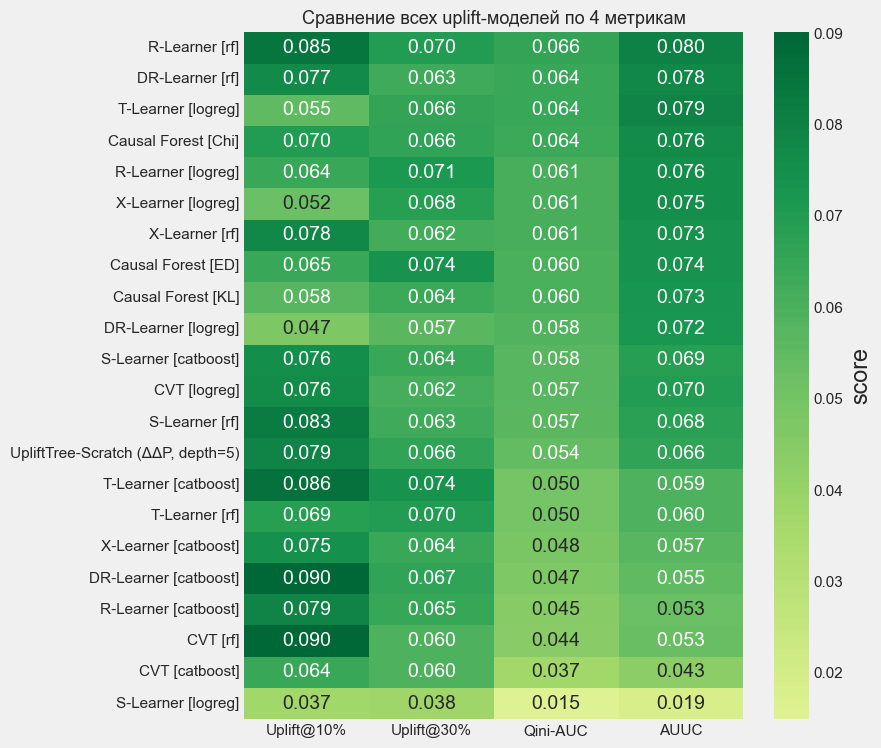

In [45]:
heatmap_df = results_df.set_index("Модель")[metric_cols]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(heatmap_df))))
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="RdYlGn",
    center=0, cbar_kws={"label": "score"}, ax=ax,
)
ax.set_title("Сравнение всех uplift-моделей по 4 метрикам", fontsize=13)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

> **Как читать heatmap.** Зелёный — хорошо, красный — плохо. Колонки — метрики (4 шт.), строки — модели (отсортированы по убыванию Qini-AUC). Хорошие модели выделяются _всеми зелёными_ ячейками во всех колонках; плохие — красными.

### 13.3. Qini-кривые: главный визуал uplift-моделей

Чтобы не загромождать график 22 кривыми, выберем **лучший вариант (по Qini-AUC) для каждого из 7 семейств** и нарисуем их вместе:

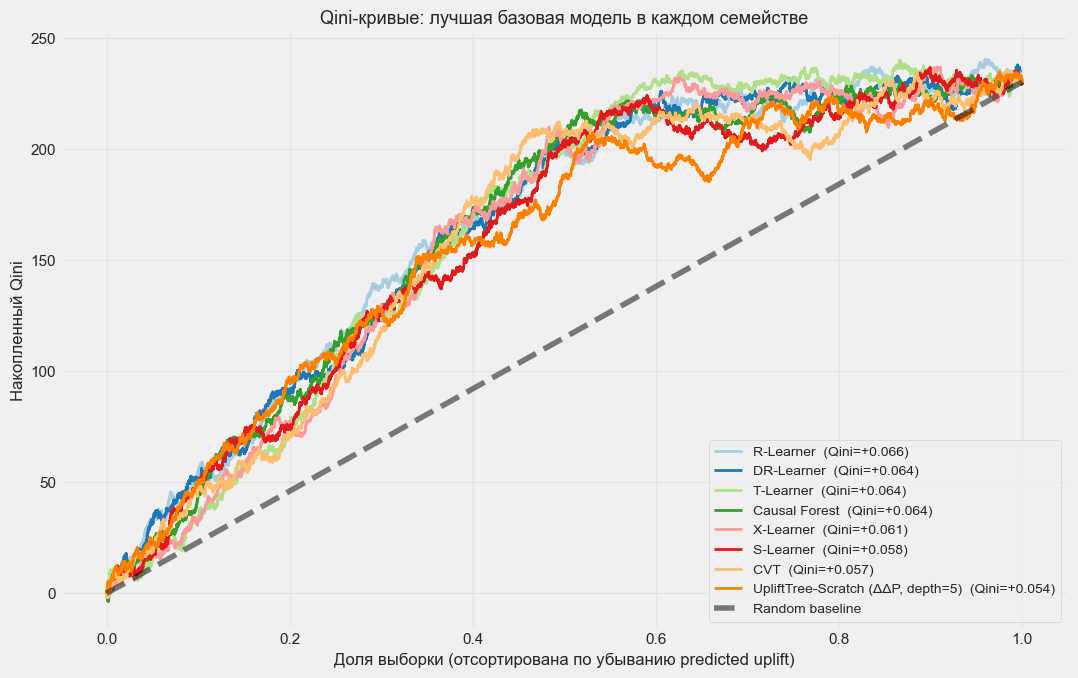

In [46]:
# Группируем модели по семейству (S-Learner, T-Learner, ...) и берём лучшую базовую модель
def family(name: str) -> str:
    # 'S-Learner [catboost]' -> 'S-Learner'
    return name.split(" [")[0]

best_per_family = {}
for name, info in RESULTS.items():
    fam = family(name)
    if fam not in best_per_family or info["Qini-AUC"] > best_per_family[fam][1]["Qini-AUC"]:
        best_per_family[fam] = (name, info)

fig, ax = plt.subplots(figsize=(11, 7))
for fam, (full_name, info) in sorted(best_per_family.items(),
                                     key=lambda kv: -kv[1][1]["Qini-AUC"]):
    x, y = qini_curve_scratch(y_test, t_test, info["uplift"])
    auc = info["Qini-AUC"]
    ax.plot(x, y, label=f"{fam}  (Qini={auc:+.3f})", linewidth=2)

# random baseline
random_x = np.linspace(0, 1, 100)
n_test = len(y_test)
# случайная модель: пропорциональный накопительный uplift
total_uplift = ((y_test * (t_test == 1)).sum()
                - (y_test * (t_test == 0)).sum() * (t_test == 1).sum() / max((t_test == 0).sum(), 1))
ax.plot([0, 1], [0, total_uplift], "k--", alpha=0.5, label="Random baseline")

ax.set_xlabel("Доля выборки (отсортирована по убыванию predicted uplift)", fontsize=12)
ax.set_ylabel("Накопленный Qini", fontsize=12)
ax.set_title("Qini-кривые: лучшая базовая модель в каждом семействе", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Как читать график.**
- Чёрная пунктирная линия — _случайная_ модель. Если ваша кривая лежит на ней — модель ничему не научилась.
- Кривые, выгибающиеся _вверх_ от диагонали — это _хорошие_ модели. Чем выгиб круче, тем больше Qini-AUC.
- Если в начале кривая идёт круто вверх, а к концу выходит на плато или спускается — это нормально: в верхушке Persuadables, к концу Lost Causes и Sleeping Dogs.

### 13.4. Базовая модель vs семейство: какая комбинация выигрывает?

Где-то LogReg вообще проваливается (S-Learner), где-то — конкурирует с CatBoost (T-Learner, R-Learner). Это _разные_ задачи для базовой модели в разных семействах:

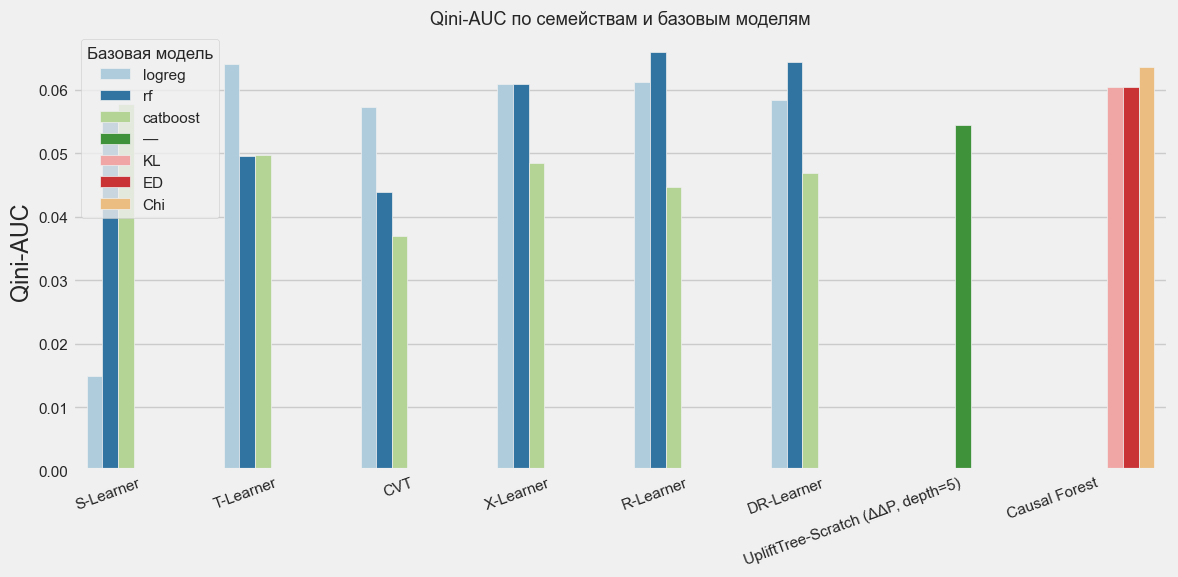

In [47]:
# извлечём базовую модель из имени, если она есть
def base_of(name: str) -> str:
    if "[" in name and "]" in name:
        return name.split("[")[1].rstrip("]")
    return "—"

bar_df = pd.DataFrame([
    {"Семейство": family(n),
     "Базовая модель": base_of(n),
     "Qini-AUC": info["Qini-AUC"]}
    for n, info in RESULTS.items()
])

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=bar_df, x="Семейство", y="Qini-AUC", hue="Базовая модель", ax=ax)
ax.axhline(0, color="k", linewidth=0.8)
ax.set_title("Qini-AUC по семействам и базовым моделям", fontsize=13)
ax.set_ylabel("Qini-AUC"); ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Что видно.**
- В семействах S-Learner и CVT линейная модель (`logreg`) систематически проигрывает — потому что _обе_ архитектуры плохо работают с линейной базой (S-Learner — по уже описанной причине; CVT — потому что Z часто плохо приближается линейной границей).
- В T/X/R/DR — `logreg` неожиданно конкурентен. Это потому, что задача «оценить эффект на двух подвыборках» более устойчива к выбору модели.
- Бустинг и лес идут плотным пелотоном. На Hillstrom разница между ними часто в пределах шума.

### 13.5. Sanity-check: персонализирует ли модель?

Это критически важный visual. Если модель — хорошая uplift-модель, **распределение её предсказаний** должно быть _широким_ (есть Persuadables с +0.2 и Sleeping Dogs с −0.05). Если предсказания все вокруг ATE = +0.045 — модель _не персонализирует_ и фактически бесполезна для таргетинга.

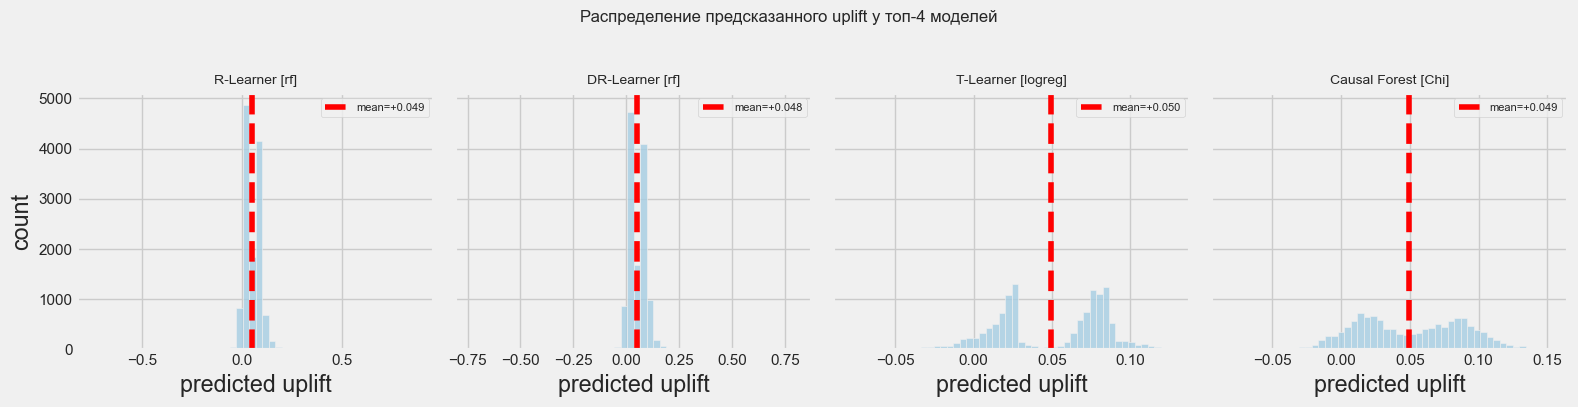

In [48]:
# берём 4 лучших по Qini-AUC модели
top4 = sorted(RESULTS.items(), key=lambda kv: -kv[1]["Qini-AUC"])[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, info) in zip(axes, top4):
    ax.hist(info["uplift"], bins=50, alpha=0.8)
    ax.axvline(info["uplift"].mean(), color="red", linestyle="--",
               label=f"mean={info['uplift'].mean():+.3f}")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("predicted uplift")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.suptitle("Распределение предсказанного uplift у топ-4 моделей", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

**Что видно.** Ширина гистограммы — мера того, насколько модель «знает», кому отправлять, а кому нет. Узкая гистограмма (всё вокруг 0) → модель _не различает_ клиентов и эквивалентна простому ATE. Широкая → модель действительно учит индивидуальные эффекты.

> **На что обратить внимание в production.** Если модель предсказывает _только_ положительный uplift — она не отличает Sleeping Dogs от Lost Causes. Полезно намеренно проверять, есть ли в распределении отрицательный хвост (Sleeping Dogs). На Hillstrom его в основном нет, потому что письмо про женские товары почти никому не вредит — а в реальной задаче (push-уведомления, спам, агрессивное промо) Sleeping Dogs могут быть значительной долей базы.

### 13.6. Bizness-интерпретация: сколько денег спасает uplift-модель?

Финальный взгляд на результаты — **в деньгах**. Допустим, вы можете отправить рассылку только 30% базы, и хотите получить максимум визитов. Сколько процентов прироста даёт лучшая модель vs случайный таргетинг?

In [49]:
# Сравним на Hillstrom: Uplift@30% лучшей модели vs наивный ATE
best_name, best_info = sorted(RESULTS.items(),
                              key=lambda kv: -kv[1]["Qini-AUC"])[0]
best_u30 = best_info["Uplift@30%"]

# ATE в test (то, что получили бы случайным таргетингом)
ate_test = (y_test[t_test == 1].mean() - y_test[t_test == 0].mean())

print(f"Лучшая модель: {best_name}")
print(f"Её Uplift@30% = {best_u30:+.4f}")
print(f"Простой ATE   = {ate_test:+.4f}")
print()
print(f"Если потратить рассылку на 30% базы:")
print(f"  • случайный таргетинг → прирост в среднем {ate_test*100:.2f} п.п. визитов")
print(f"  • лучшая uplift-модель → прирост {best_u30*100:.2f} п.п. визитов на топ-30%")
print(f"  → uplift-модель даёт в {best_u30/ate_test:.2f}x больше эффекта при том же бюджете")

Лучшая модель: R-Learner [rf]
Её Uplift@30% = +0.0703
Простой ATE   = +0.0359

Если потратить рассылку на 30% базы:
  • случайный таргетинг → прирост в среднем 3.59 п.п. визитов
  • лучшая uplift-модель → прирост 7.03 п.п. визитов на топ-30%
  → uplift-модель даёт в 1.96x больше эффекта при том же бюджете


---

<a id="conclusion"></a>
## 14. Заключение и рекомендации

### 14.1. Шпаргалка: «Какую модель брать?»

Решающее дерево по жизненной ситуации:

```
Размер данных < 5К?
└── Да: CVT (одна модель, минимум variance) или S-Learner
└── Нет:
 Treatment рандомизирован?
 ├── Да (RCT, A/B-тест):
 │ └── T-Learner (бустинг) — простой и сильный бэйзлайн
 │ Если есть лишний compute и хочется лучше → R-Learner
 └── Нет (наблюдательные данные):
 ├── Boostrapping ошибок propensity заметен → DR-Learner
 ├── Хочешь доверительные интервалы → Causal Forest (honest)
 └── По умолчанию → R-Learner
```

Чуть подробнее:

| Ситуация | Главная рекомендация | Запасной вариант |
|---|---|---|
| **Прототип, MVP, надо за час** | S-Learner с CatBoost | T-Learner с CatBoost |
| **Сбалансированный RCT, бинарный Y** | T-Learner с бустингом | CVT с бустингом |
| **Сильный дисбаланс T/C** (95/5) | X-Learner | DR-Learner |
| **Наблюдательные данные** (не RCT) | DR-Learner (cross-fitting обязателен) | R-Learner |
| **Сильные `T × X` взаимодействия** | Causal Forest | X-Learner с deep RF |
| **Малый датасет (< 5K)** | CVT (LogReg) | S-Learner (LogReg) |
| **Нужны CI для $\hat\tau$** | Causal Forest (honest) | DR-Learner + bootstrap |
| **Нужны теоретические гарантии** | R-Learner или DR-Learner с CV | — |

### 14.2. Семь pitfalls, на которых чаще всего обжигаются

> Эта секция — самая ценная для тех, кто делает свой первый production uplift-проект. Каждый из этих пунктов был в реальных проектах.

1. **Валидируете ROC-AUC по `Y` вместо uplift-метрик.**
 _Симптом._ Тимлид смотрит ROC-AUC и говорит «модель хорошая». Но мы оптимизируем _ранжирование по τ_, не по `Y`. Хорошая uplift-модель может иметь _плохой_ ROC-AUC по target — потому что она преднамеренно «расфокусирована» по abs probability ради хорошего ранжирования по разности.
 _Лекарство._ Только Qini-AUC / AUUC / Uplift@k.

2. **Не стратифицируете split по `T`.**
 _Симптом._ Иногда `t_test.mean() = 0.05`, а train был 0.5 — все ваши метрики бессмысленны.
 _Лекарство._ `train_test_split(..., stratify=t)`.

3. **Игнорируете positivity.**
 _Симптом._ В каком-то сегменте признаков treatment _никогда_ не назначался → $\hat e(x) \to 0$. IPW-веса в DR/X взрываются. Один объект может «перевесить» весь датасет.
 _Лекарство._ Клиппинг `e ∈ [0.05, 0.95]`. Если без клиппинга ничего не помогает — данные не подходят, нужно собрать experimentation в этом сегменте.

4. **Линейный S-Learner.**
 _Симптом._ Все клиенты получают _одинаковый_ predicted uplift = коэффициент при `T`. Гистограмма предсказаний — это одна вертикальная линия.
 _Лекарство._ T-Learner вместо S-Learner, или явные взаимодействия `T × X` в признаках.

5. **Тот же split для nuisance и final τ.**
 _Симптом._ В R/DR/X — модели `μ̂, ê` помнят train-точки, остатки занижены, $\hat\tau$ смещён.
 _Лекарство._ K-fold cross-fitting, как в наших реализациях.

6. **«Среднее uplift» как метрика.**
 _Симптом._ «У всех моделей средний uplift +0.045 — все одинаковые!» Но это _ATE_, а не CATE: в RCT он одинаков по построению.
 _Лекарство._ Сравнивать _ранжирующие_ метрики (Qini, AUUC, Uplift@k).

7. **Не проверяете распределение предсказаний.**
 _Симптом._ Метрики Qini-AUC = 0.05, выше random — но в производстве модель ничего не решает.
 _Лекарство._ Гистограмма $\hat\tau(X_{\text{test}})$. Если узкая (всё ≈ ATE) — модель _не персонализирует_, эффект статистически есть, но бизнесово полезности ноль.

### 14.3. Что почитать / посмотреть дальше

**Обзорные работы (с чего начать).**
- **Gutierrez & Gérardy (2017)** — *Causal Inference and Uplift Modeling: A Review of the Literature*, JMLR. Лучший единый обзор на 30 страниц.
- **Курс «Causal Inference for the Brave and True»** (Matheus Facure) — практический туториал на Python с интуициями. Прекрасное продолжение этой тетрадки.

**Оригинальные статьи моделей.**
- **Künzel, Sekhon, Bickel & Yu (2019)** — *Metalearners for estimating heterogeneous treatment effects using machine learning*, PNAS. X-Learner.
- **Nie & Wager (2021)** — *Quasi-oracle estimation of heterogeneous treatment effects*, Biometrika. R-Learner и теория квази-оракула.
- **Athey & Imbens (2016)** — *Recursive partitioning for heterogeneous causal effects*, PNAS. Основа Causal Forest.
- **Athey, Tibshirani & Wager (2019)** — *Generalized Random Forests*, Annals of Statistics. Honest forest и доверительные интервалы.
- **Jaskowski & Jaroszewicz (2012)** — *Uplift modeling for clinical trial data*, ICML. Class Variable Transformation.

**Продакшен-инструменты.**
- [`scikit-uplift`](https://www.uplift-modeling.com/) — самая удобная библиотека для S/T/CVT.
- [`causalml`](https://causalml.readthedocs.io/) (Uber) — все meta-learners + Causal Forest.
- [`econml`](https://econml.azurewebsites.net/) (Microsoft) — DML, R-Learner, Orthogonal Forests.

**Бизнес-кейсы.**
- Запросите в поиске `uplift modeling case study Wayfair / Booking / Lyft` — у крупных компаний есть публичные блог-посты с реальными кейсами и архитектурой.

### 14.4. Что мы построили в этой тетрадке

- **7 моделей** (S-Learner, T-Learner, CVT, X-Learner, R-Learner, DR-Learner, Causal Forest), каждая с:
 - подробной теорией и интуицией
 - учебным примером «карандашом»
 - реализацией с нуля
 - применением со всеми тремя базовыми моделями (LogReg / RandomForest / CatBoost)
 - сверкой с эталоном (sklift / causalml)
 - резюме «когда брать, когда нет»
- **3 uplift-метрики** (Uplift@k, Qini-AUC, AUUC) реализованы с нуля и сверены с библиотечными.
- **EDA** датасета Hillstrom с проверкой рандомизации.
- **Финальное сравнение**: таблица 22 конфигураций, heatmap, Qini-кривые, распределения uplift, бизнес-интерпретация.
- **Шпаргалка** по выбору модели и **семь pitfalls**.

Тетрадка готова для:
- **самостоятельного изучения** — от первой строки до последней без пробелов;
- **прохождения собеседований** на ML/DS позиции, где спрашивают про uplift;
- **референса в production** — код модульный, проверенный, можно переиспользовать.

Удачи в построении uplift-моделей.